# AI2002 - Group 5 - Review Chatbot for Hotel Question Answering

## Đề tài: Xây dựng Chatbot thông minh hỗ trợ trả lời câu hỏi và tư vấn khách sạn dựa trên tập dữ liệu đánh giá TripAdvisor (Hotel Review Question Answering)

## 0. Cài đặt môi trường

Trong dự án nghiên cứu về **AI2002 - Review Chatbot for Hotel Question Answering**, nhóm nghiên cứu đã thiết lập các thư viện và công cụ nền tảng sau:

1. **Pandas**: Dùng để cấu trúc hóa dữ liệu lớn từ file .csv thành DataFrame, thực hiện tiền xử lý, lọc theo địa phương/ngôn ngữ và biến đổi dữ liệu đánh giá khách sạn.
2. **NumPy**: Hỗ trợ các phép toán ma trận, vector hóa các trọng số điểm số và tính toán số học hiệu năng cao.
3. **SQLite3**: Quản trị cơ sở dữ liệu quan hệ cục bộ (`hotel_chatbot_research.db`), giúp lưu trữ có cấu trúc các bảng thực thể khách sạn, các khía cạnh dịch vụ và truy vấn nhanh chóng bằng câu lệnh SQL.
4. **Matplotlib / Seaborn**: Hỗ trợ trực quan hóa phân bố điểm đánh giá, tỉ lệ đánh giá theo tỉnh thành/hạng sao, và thống kê độ dài review.
5. **NLTK & Scikit-learn**: Cung cấp công cụ xử lý ngôn ngữ tự nhiên (NLP) cơ bản, tách từ, loại bỏ từ dừng (stop words), xây dựng ma trận đặc trưng văn bản (TF-IDF Vectorizer) và đo lường độ tương đồng ngữ nghĩa (Cosine Similarity) phục vụ cơ chế truy xuất câu trả lời (Question Answering).

In [ ]:
import os
import re
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Kiểm tra phiên bản các thư viện chính
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SQLite3 version: {sqlite3.sqlite_version}")

# Kiểm tra các thư viện NLP / Machine Learning hỗ trợ nếu có sẵn
try:
    import sklearn
    print(f"Scikit-learn version: {sklearn.__version__}")
except ImportError:
    print("Scikit-learn: Chưa cài đặt (có thể cài đặt qua `pip install scikit-learn`)")

try:
    import nltk
    print(f"NLTK version: {nltk.__version__}")
except ImportError:
    print("NLTK: Chưa cài đặt (có thể cài đặt qua `pip install nltk`)")

# Khởi tạo kết nối SQLite (tạo file database local cho hệ thống Chatbot khách sạn)
conn = sqlite3.connect('hotel_chatbot_research.db')

print("\n--- Môi trường cho Hotel Review Chatbot đã được khởi tạo thành công ---")

## 1. Nhập và Kiểm tra Dataset (Dataset Loading & Exploration)

Trong phần này, nhóm sẽ thực hiện các bước chuẩn bị và khảo sát ban đầu:
1. **Tải tập dữ liệu nghiên cứu**: Đọc tập dữ liệu đánh giá khách sạn từ file CSV (`tripadvisor_review_hotel_dataset.csv`). Chương trình tự động kiểm tra sự tồn tại của file ở thư mục hiện tại, thư mục lưu trữ dữ liệu `Data (Dataset, Data Frame, Chart Images)/` hoặc trên Google Drive.
2. **Chuyển đổi vào Pandas DataFrame**: Sử dụng bộ mã hóa UTF-8 để đảm bảo hiển thị chuẩn xác tiếng Việt và các ngôn ngữ quốc tế.
3. **Kiểm tra cấu trúc và các trường thông tin quan trọng**:
   - **Thông tin cơ sở lưu trú**: `hotel_name`, `hotel_province`, `hotel_address`, `hotel_star`.
   - **Điểm đánh giá và các khía cạnh dịch vụ**: `normalized_score`, `Value`, `Rooms`, `Location`, `Cleanliness`, `Service`, `Sleep_Quality`.
   - **Dữ liệu văn bản phục vụ Chatbot Hỏi Đáp (QA)**: `normalized_title` (tiêu đề đánh giá), `normalized_content` (nội dung đánh giá chi tiết), `Word_count`, `language_code`, `language`.
   - **Bối cảnh chuyến đi & Thời gian**: `trip_type`, `Date`, `month`, `year`.

In [ ]:
import os
import pandas as pd

# Tạo thư mục lưu trữ biểu đồ trực quan hóa nếu chưa tồn tại
os.makedirs('charts_img', exist_ok=True)

# Danh sách các đường dẫn ứng viên của dataset (hỗ trợ cả Local và Google Colab)
candidate_paths = [
    'Data (Dataset, Data Frame, Chart Images)/tripadvisor_review_hotel_dataset.csv',
    'tripadvisor_review_hotel_dataset.csv',
    '/content/drive/MyDrive/Data (Dataset, Data Frame, Chart Images)/tripadvisor_review_hotel_dataset.csv',
    '/content/drive/MyDrive/tripadvisor_review_hotel_dataset.csv',
    '/content/tripadvisor_review_hotel_dataset.csv'
]

file_path = None
for path in candidate_paths:
    if os.path.exists(path):
        file_path = path
        print(f"Đã tìm thấy dataset tại: {file_path}")
        break

if file_path is None:
    file_path = candidate_paths[0]
    print(f"Cảnh báo: Chưa tìm thấy file dataset. Hãy đảm bảo file '{os.path.basename(file_path)}' đã được tải lên.")

# Tiến hành đọc file CSV
try:
    df = pd.read_csv(file_path, encoding='utf-8', low_memory=False)
    print(f"Kích thước tập dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")
    print("\nCác cột dữ liệu phục vụ nghiên cứu:")
    print(list(df.columns))
    
    # Hiển thị 5 dòng đầu tiên
    print("\nXem trước 5 dòng đầu tiên:")
    display(df.head())
except Exception as e:
    print(f"Lỗi khi đọc file CSV: {e}")

## 2. Data Analysis with SQL & Python

Tập trung giải quyết 3 Research Questions:

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*



### 2.1. Đưa dữ liệu từ DataFrame vào bảng SQLite để truy vấn.

In [3]:
# Re-establish connection as it might have been closed by previous cells
conn = sqlite3.connect('freight_pricing_research.db')

# Đưa dữ liệu vào SQLite table để thực hiện truy vấn
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
print("Added data to 'supply_chain'.")

Added data to 'supply_chain'.


### 2.2. SQL Queries để giải quyết 3 RQ
**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*

In [4]:
# 1. [RQ1] Ảnh hưởng của thị trường và doanh số trung bình
query1 = """
SELECT
    Market,
    COUNT(*) as Total_Orders,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY Market
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query1, conn))

,Market,Total_Orders,Avg_Sales
0,Europe,50252,216.357494
1,Pacific Asia,41260,200.526993
2,LATAM,51594,199.201706
3,Africa,11614,197.559232
4,USCA,25799,196.384694


In [5]:
# 2. [RQ1] Tương quan giữa phương thức vận chuyển và doanh số
query2 = """
SELECT
    [Shipping Mode],
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query2, conn))

,Shipping Mode,Avg_Sales
0,Standard Class,204.380354
1,First Class,204.011281
2,Second Class,202.903363
3,Same Day,199.499698


In [6]:
# 3. [RQ2] Mối liên hệ giữa số lượng sản phẩm (Demand) và doanh số
query3 = """
SELECT
    [Order Item Quantity],
    AVG(Sales) as Avg_Sales
FROM supply_chain
WHERE [Order Item Quantity] > 1
GROUP BY [Order Item Quantity]
ORDER BY [Order Item Quantity]
LIMIT 10;
"""
display(pd.read_sql_query(query3, conn))

,Order Item Quantity,Avg_Sales
0,2,110.589542
1,3,166.691618
2,4,221.694599
3,5,277.391077


In [7]:
# 4. [RQ3] Tổng doanh thu theo phương thức vận chuyển
query4 = """
SELECT
    [Shipping Mode],
    SUM(Sales) as Total_Revenue
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Total_Revenue DESC;
"""
display(pd.read_sql_query(query4, conn))

,Shipping Mode,Total_Revenue
0,Standard Class,2.202239e+07
1,Second Class,7.145445e+06
2,First Class,5.674370e+06
3,Same Day,1.942529e+06


In [8]:
# 5. [RQ3] Lợi nhuận trung bình theo phân khúc khách hàng
query5 = """
SELECT
    [Customer Segment],
    AVG([Order Profit Per Order]) as Avg_Profit
FROM supply_chain
GROUP BY [Customer Segment]
ORDER BY Avg_Profit DESC;
"""
display(pd.read_sql_query(query5, conn))

,Customer Segment,Avg_Profit
0,Consumer,22.175390
1,Corporate,21.949204
2,Home Office,21.437359


In [9]:
# 6. [RQ2] Tìm mối tương quan giữa trạng thái giao hàng và doanh số
query6 = """
SELECT
    [Delivery Status],
    ROUND(AVG(Sales), 2) AS Avg_Sales
FROM supply_chain
GROUP BY [Delivery Status]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query6, conn))

,Delivery Status,Avg_Sales
0,Advance shipping,204.80
1,Shipping on time,204.06
2,Late delivery,203.34
3,Shipping canceled,202.52


In [10]:
# 7. [RQ2] Giá sản phẩm trung bình theo phương thức vận chuyển
query7 = """
SELECT
    [Shipping Mode],
    AVG([Order Item Product Price]) as Avg_Product_Price
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Product_Price DESC;
"""
display(pd.read_sql_query(query7, conn))

,Shipping Mode,Avg_Product_Price
0,Standard Class,141.904742
1,First Class,141.405508
2,Second Class,140.453302
3,Same Day,136.118171


In [11]:
# 8. [RQ1/RQ2] Thống kê ngày giao hàng thực tế theo phương thức vận chuyển
query8 = """
SELECT
    [Shipping Mode],
    AVG([Days for shipping (real)]) as Avg_Shipping_Days
FROM supply_chain
GROUP BY [Shipping Mode];
"""
display(pd.read_sql_query(query8, conn))

,Shipping Mode,Avg_Shipping_Days
0,First Class,2.000000
1,Same Day,0.478279
2,Second Class,3.990828
3,Standard Class,3.995907


In [12]:
# 9. [RQ3] Tổng số đơn hàng theo thị trường
query9 = """
SELECT
    Market,
    COUNT(*) as Total_Orders
FROM supply_chain
GROUP BY Market
ORDER BY Total_Orders DESC;
"""
display(pd.read_sql_query(query9, conn))

,Market,Total_Orders
0,LATAM,51594
1,Europe,50252
2,Pacific Asia,41260
3,USCA,25799
4,Africa,11614


In [13]:
# 10. [RQ1] Tỷ lệ rủi ro giao trễ theo thị trường
query10 = """
SELECT
    Market,
    AVG(CAST(Late_delivery_risk AS FLOAT)) as Late_Delivery_Rate
FROM supply_chain
GROUP BY Market
ORDER BY Late_Delivery_Rate DESC;
"""
display(pd.read_sql_query(query10, conn))

,Market,Late_Delivery_Rate
0,Europe,0.552078
1,Pacific Asia,0.550460
2,USCA,0.548006
3,Africa,0.545893
4,LATAM,0.543552


In [14]:
# 11. [RQ1] Phân tích doanh số theo mức chiết khấu
query11 = """
SELECT
    CASE
        WHEN [Order Item Discount Rate] < 0.05 THEN 'Low Discount'
        WHEN [Order Item Discount Rate] BETWEEN 0.05 AND 0.15 THEN 'Medium Discount'
        ELSE 'High Discount'
    END AS Discount_Level,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY Discount_Level;
"""
display(pd.read_sql_query(query11, conn))

,Discount_Level,Avg_Sales
0,High Discount,203.827159
1,Low Discount,203.715490
2,Medium Discount,203.765330


In [15]:
# 12. [RQ2] Tương quan giữa ngày vận chuyển và doanh số
query12 = """
SELECT
    [Days for shipping (real)] as Shipping_Days,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Days for shipping (real)]
ORDER BY Shipping_Days;
"""
display(pd.read_sql_query(query12, conn))

,Shipping_Days,Avg_Sales
0,0,202.032896
1,1,196.736407
2,2,204.400251
3,3,203.263487
4,4,204.259195
5,5,204.291286
6,6,203.498971


In [16]:
# 13. [RQ3] Phân tích doanh thu theo phân khúc khách hàng
query13 = """
SELECT
    [Customer Segment],
    SUM(Sales) AS Total_Revenue,
    COUNT(*) AS Order_Count,
    AVG(Sales) AS Avg_Per_Order
FROM supply_chain
GROUP BY [Customer Segment];
"""
display(pd.read_sql_query(query13, conn))

,Customer Segment,Total_Revenue,Order_Count,Avg_Per_Order
0,Consumer,1.909579e+07,93504,204.224313
1,Corporate,1.116841e+07,54789,203.843962
2,Home Office,6.520538e+06,32226,202.337802


In [17]:
# 14. [RQ1] Hiệu suất lợi nhuận trên mỗi đơn hàng theo phương thức vận chuyển
query14 = """
SELECT
    [Shipping Mode],
    AVG([Order Item Profit Ratio]) AS Avg_Profit_Ratio
FROM supply_chain
GROUP BY [Shipping Mode];
"""
display(pd.read_sql_query(query14, conn))

,Shipping Mode,Avg_Profit_Ratio
0,First Class,0.126486
1,Same Day,0.117568
2,Second Class,0.118427
3,Standard Class,0.120143


In [18]:
# 15. [RQ3] Thống kê theo thị trường và phương thức vận chuyển
query15 = """
SELECT
    Market,
    [Shipping Mode],
    COUNT(*) AS Sample_Size,
    AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY Market, [Shipping Mode]
ORDER BY Avg_Sales DESC;
"""
display(pd.read_sql_query(query15, conn))

,Market,Shipping Mode,Sample_Size,Avg_Sales
0,Europe,Standard Class,29740,217.624071
1,Europe,First Class,7892,216.592194
2,Europe,Second Class,9861,214.256447
3,Europe,Same Day,2759,209.542766
4,Pacific Asia,First Class,6301,201.444140
5,Africa,Same Day,668,201.306815
6,Pacific Asia,Standard Class,24586,201.115619
7,Pacific Asia,Second Class,8147,200.130688
8,LATAM,First Class,7886,199.879694
9,LATAM,Standard Class,31119,199.344002


In [19]:
# 16. [RQ1] Tác động của rủi ro giao trễ lên doanh số
query16 = """
SELECT
    Late_delivery_risk,
    COUNT(*) AS Order_Count,
    AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY Late_delivery_risk
ORDER BY Late_delivery_risk;
"""
display(pd.read_sql_query(query16, conn))

,Late_delivery_risk,Order_Count,Avg_Sales
0,0,81542,204.291528
1,1,98977,203.344163


In [20]:
# 17. [RQ2] Top 10 danh mục sản phẩm có nhu cầu vận chuyển cao nhất
query17 = """
SELECT
    [Category Name],
    COUNT(*) as Total_Orders,
    AVG(Sales) as Avg_Sales
FROM supply_chain
GROUP BY [Category Name]
ORDER BY Total_Orders DESC
LIMIT 10;
"""
display(pd.read_sql_query(query17, conn))

,Category Name,Total_Orders,Avg_Sales
0,Cleats,24551,180.519848
1,Men's Footwear,22246,129.990005
2,Women's Apparel,21035,149.645828
3,Indoor/Outdoor Games,19298,149.704317
4,Fishing,17325,399.980011
5,Water Sports,15540,200.376106
6,Camping & Hiking,13729,299.980011
7,Cardio Equipment,12487,295.895187
8,Shop By Sport,10984,119.220870
9,Electronics,3156,117.564843


In [21]:
# 18. [RQ2] Chênh lệch ngày giao dự kiến vs thực tế theo phương thức vận chuyển
query18 = """
SELECT
   [Shipping Mode],
   AVG([Days for shipment (scheduled)] - [Days for shipping (real)]) AS Avg_Delay_Diff,
   AVG(Sales) AS Avg_Sales
FROM supply_chain
GROUP BY [Shipping Mode]
ORDER BY Avg_Delay_Diff;
"""
display(pd.read_sql_query(query18, conn))

,Shipping Mode,Avg_Delay_Diff,Avg_Sales
0,Second Class,-1.990828,202.903363
1,First Class,-1.000000,204.011281
2,Same Day,-0.478279,199.499698
3,Standard Class,0.004093,204.380354


In [22]:
# 19. [RQ3] Top 5 thị trường có doanh thu cao nhất
query19 = """
SELECT
    Market,
    SUM(Sales) AS Total_Revenue
FROM supply_chain
GROUP BY Market
ORDER BY Total_Revenue DESC
LIMIT 5;
"""
display(pd.read_sql_query(query19, conn))

,Market,Total_Revenue
0,Europe,1.087240e+07
1,LATAM,1.027761e+07
2,Pacific Asia,8.273744e+06
3,USCA,5.066529e+06
4,Africa,2.294453e+06


In [23]:
# 20. [RQ3] So sánh giá trị đơn hàng giữa các loại thanh toán
query20 = """
SELECT
    Type as Payment_Type,
    AVG(Sales) AS Avg_Sales,
    SUM(Sales) AS Total_Sales
FROM supply_chain
GROUP BY Type;
"""
display(pd.read_sql_query(query20, conn))

,Payment_Type,Avg_Sales,Total_Sales
0,CASH,205.068524,4.022624e+06
1,DEBIT,203.143916,1.407686e+07
2,PAYMENT,203.483552,8.490351e+06
3,TRANSFER,204.376280,1.019490e+07


## 3. EDA & Data Cleaning

Trong mục này, nhóm sẽ thực hiện phân tích chi tiết đặc điểm dữ liệu và xử lý dữ liệu để chuẩn bị cho việc xây dựng mô hình AI.

### 3.1. Exploratory Data Analysis (EDA)

In [24]:
# 1. Kiểm tra kích thước và kiểu dữ liệu
print("Shape of dataset:", df.shape)
print("\nData types:")
display(df.dtypes)

# 2. Kiểm tra tỷ lệ giá trị thiếu (Missing values %)
missing_pct = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values:")
display(missing_pct[missing_pct > 0])

# 3. Thống kê mô tả và phát hiện Outliers sơ bộ
display(df.describe())

Shape of dataset: (180519, 53)

Data types:


Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          


Percentage of missing values:


Customer Lname           0.004432
Customer Zipcode         0.001662
Order Zipcode           86.239676
Product Description    100.000000
dtype: float64

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


### 3.2. Phát hiện Outliers
Kiểm tra các cột số quan trọng như `Sales`, `Benefit per order`, `Order Item Quantity` và `Product Price` để xem có giá trị ngoại lai hay không.

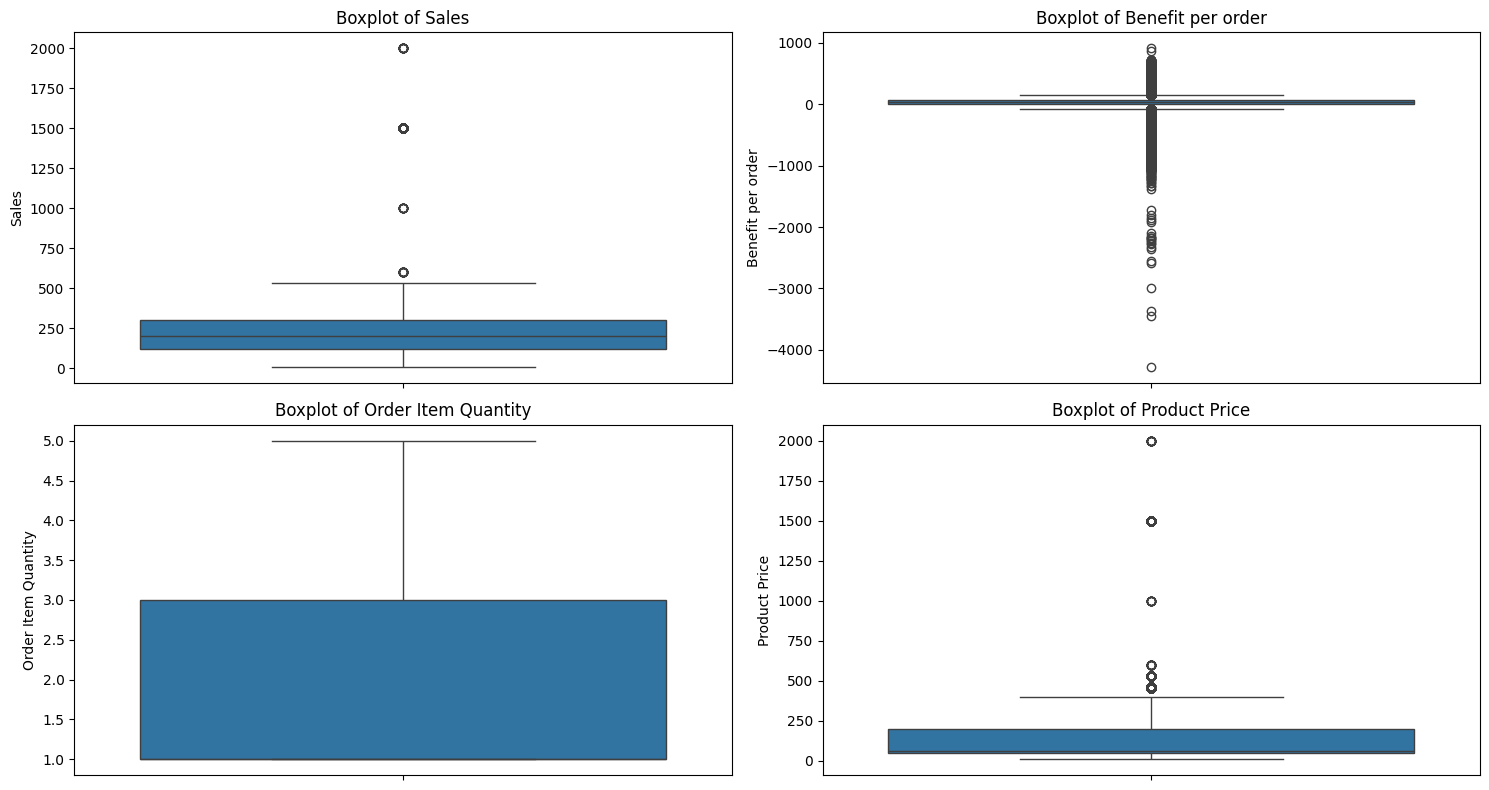

In [25]:
# 3.2. Phát hiện Outliers
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 3.3. Data Cleaning
Các bước thực hiện:
1. Xử lý giá trị trùng lặp (Duplicates).
2. Điền giá trị thiếu (Imputation) nếu có.
3. Mã hóa dữ liệu phân loại (Encoding Categorical Variables).

In [26]:
# 3.3. Data Cleaning
# 1. Loại bỏ các dòng trùng lặp
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Deleted {duplicate_count} duplicate row(s).")
else:
    print("No duplicate row.")

# 2. Xử lý missing values (nếu có)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# 3. Encoding (Cập nhật danh sách cột phân loại thực tế)
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Type', 'Delivery Status', 'Customer Segment', 'Market', 'Shipping Mode']
le = LabelEncoder()

for col in cat_cols:
    if col in df.columns:
        df[f'{col}_Encoded'] = le.fit_transform(df[col])

# 4. Lưu dữ liệu sạch vào database
conn = sqlite3.connect('freight_pricing_research.db')
df.to_sql('supply_chain', conn, if_exists='replace', index=False)
conn.close()

print("\n--- Cleaning successfully ---")

No duplicate row.

--- Cleaning successfully ---


### 3.4. EDA of Data Cleaning

**Correlation Matrix**

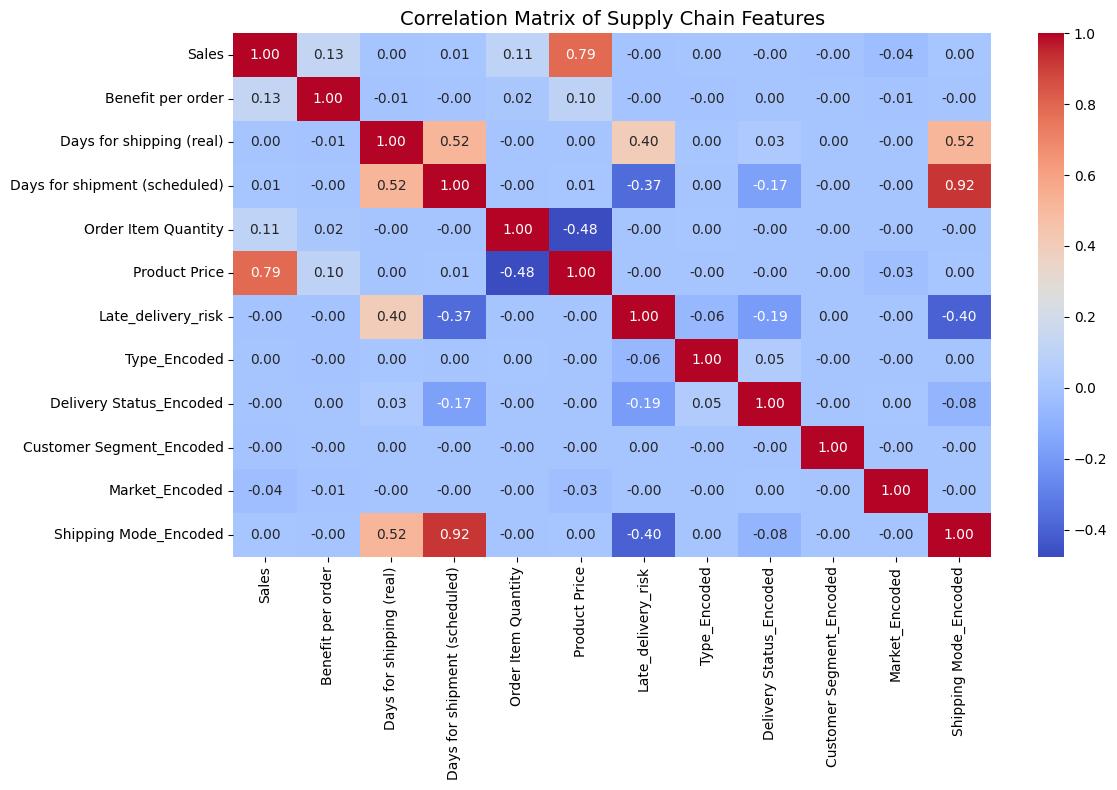

In [27]:
# Market Variables & Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# Connect to the database and fetch clean data
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# Plot the Correlation Matrix
plt.figure(figsize=(12, 8))
cols_to_corr = [
    'Sales', 'Benefit per order', 'Days for shipping (real)', 
    'Days for shipment (scheduled)', 'Order Item Quantity', 
    'Product Price', 'Late_delivery_risk', 
    'Type_Encoded', 'Delivery Status_Encoded', 
    'Customer Segment_Encoded', 'Market_Encoded', 'Shipping Mode_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]

sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Supply Chain Features', fontsize=14)
plt.tight_layout()
plt.savefig('charts_img/34_Correlation_Matrix.png', dpi=300, bbox_inches='tight')
plt.show()

**Outliers analysis**



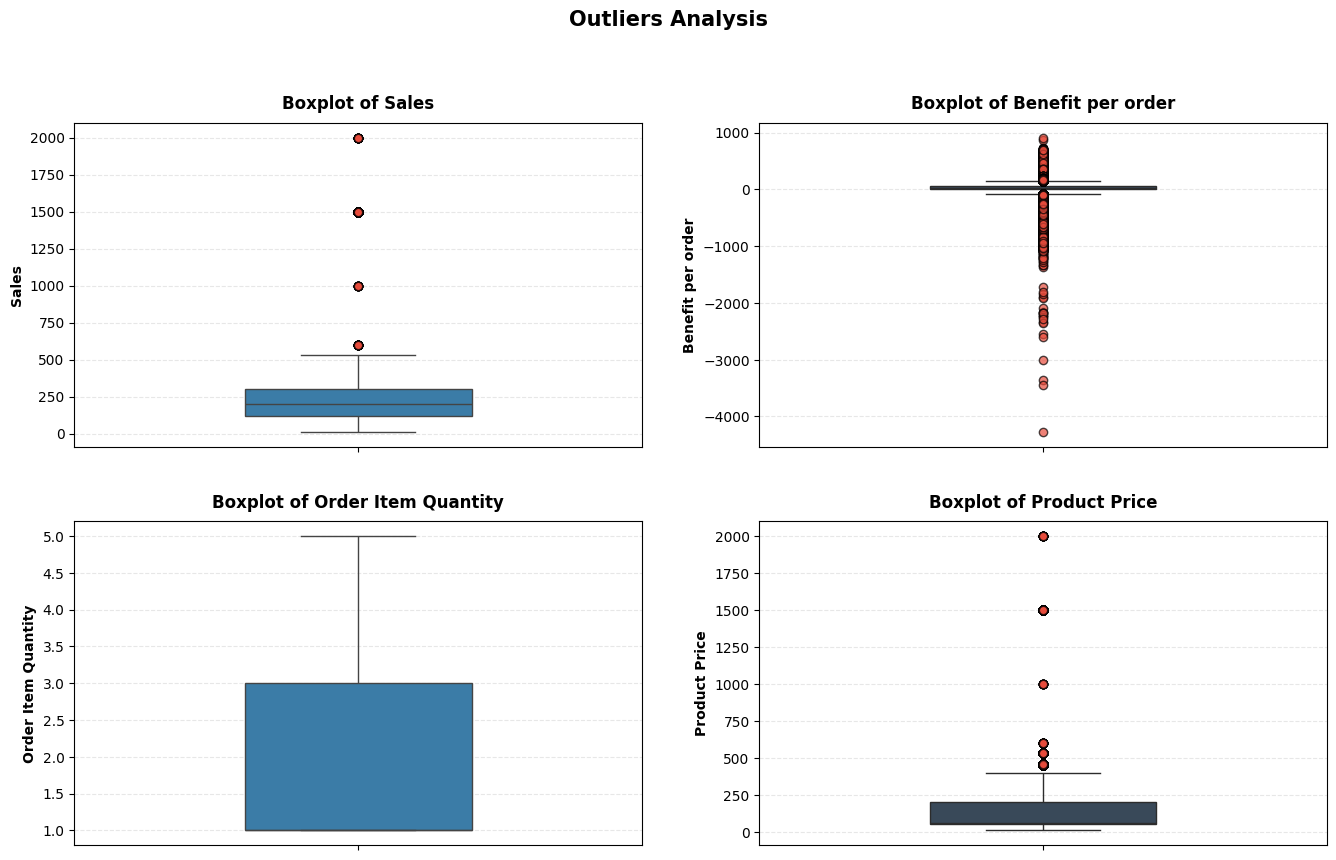

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Outliers Analysis', fontsize=15, fontweight='bold', y=0.98)

plt.tight_layout(pad=3.0)
plt.savefig('charts_img/34_outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Visualization


Trong mục này, nhóm sẽ thực hiện phân tích các RQ thoả mãn các mục title, axis labels, 1–2 Insight (nhận xét)

**RQ1:** *Yếu tố thị trường nào ảnh hưởng đến giá cước vận chuyển? - Which market factors affect transport price?*

**RQ2:** *Mô hình AI nào dự báo và tối ưu giá cước động? - Which AI model can predict and improve the price in real time?*

**RQ3:** *Dynamic pricing giúp tăng doanh thu freight bao nhiêu % so với giá cố định? - How much can dynamic pricing increase freight revenue over fixed price?*

### 4.1. [LINK TO RQ1] - Biểu đồ 1: Histogram - Khảo sát phân phối của biến chính (Sales)

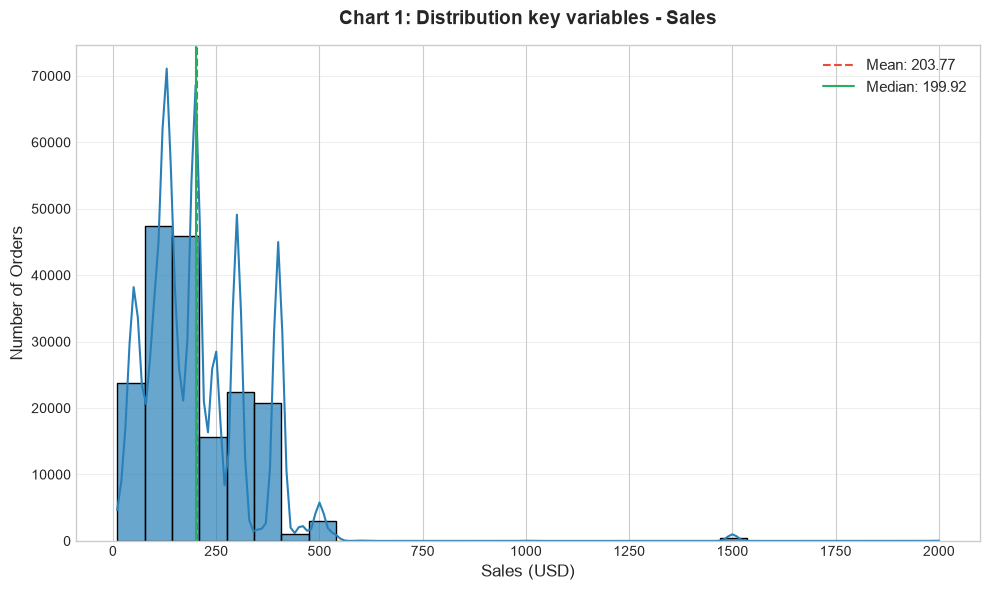

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd
import numpy as np

# 1. Kết nối database và lấy dữ liệu
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Vẽ biểu đồ Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=30, kde=True, color='#2980b9', edgecolor='black', alpha=0.7)

# 3. Thêm (Mean) và (Median) để làm rõ phân phối
mean_val = df['Sales'].mean()
median_val = df['Sales'].median()
plt.axvline(mean_val, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='#27ae60', linestyle='-', linewidth=1.5, label=f'Median: {median_val:.2f}')

# 4. Title và axis labels
plt.title('Chart 1: Distribution key variables - Sales', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Sales (USD)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# 5. Thiết lập layout và lưu img
plt.tight_layout()
plt.savefig('charts_img/41_rq1_histogram_sales.png', dpi=300, bbox_inches='tight')
plt.show()

 **INSIGHT 1:** The transaction Sales primarily ranges from 9.99 to 2000 USD, with the average sales (Mean) reaching approximately 203.77 USD and the median reaching 199.92 USD.

**INSIGHT 2:** The distribution chart shows a strong right skewness, indicating that the majority of shipping orders represent low to medium transaction values, while high-value sales (> 1000 USD) account for a small proportion of overall orders.

### 4.2. [LINK TO RQ1] - Biểu đồ 2: Bar Chart - So sánh giá trị giữa các nhóm/phân loại.

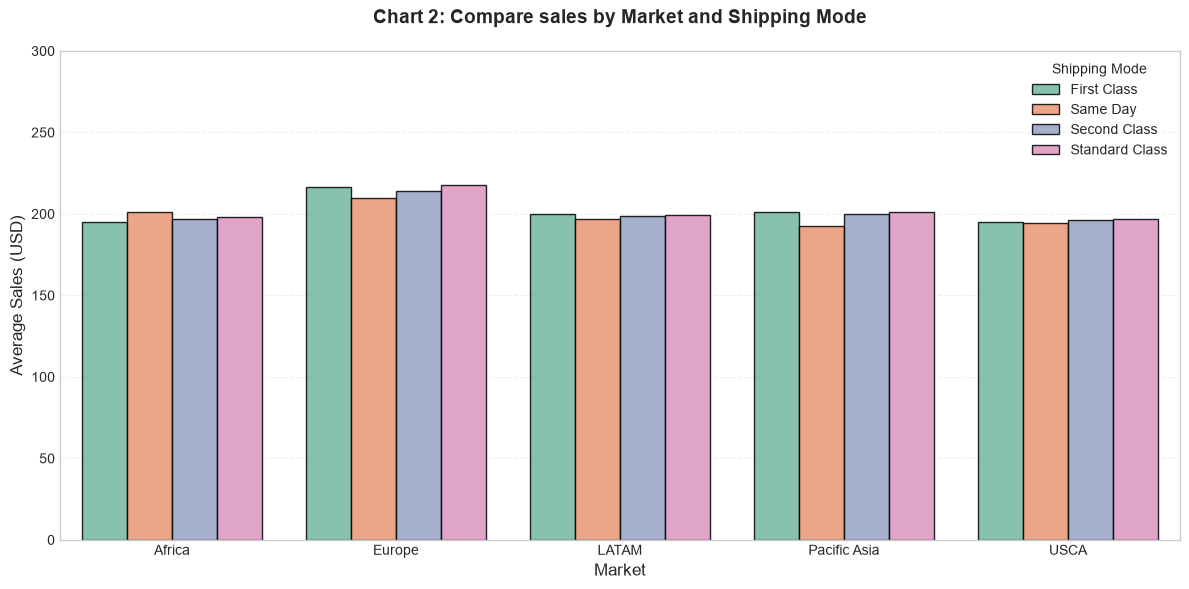

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Nhóm dữ liệu theo Market và Shipping Mode để tính trung bình Sales
grouped_df = df.groupby(['Market', 'Shipping Mode'])['Sales'].mean().reset_index()

# 3. Thiết lập kích thước biểu đồ và vẽ Bar Chart
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='Market',
    y='Sales',
    hue='Shipping Mode',
    data=grouped_df,
    palette='Set2',
    edgecolor='black',
    alpha=0.85
)

# 4. Thiết lập Title và Axis Labels
plt.title('Chart 2: Compare sales by Market and Shipping Mode', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Market', fontsize=12)
plt.ylabel('Average Sales (USD)', fontsize=12)
plt.ylim(0, 300)
plt.legend(title='Shipping Mode', fontsize=10, title_fontsize=10, loc='upper right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 5. Thiết lập layout và lưu img
plt.tight_layout()
plt.savefig('charts_img/42_rq1_bar_chart_sales.png', dpi=300, bbox_inches='tight')
plt.show()

**INSIGHT 1:** Europe consistently shows the highest average transaction sales across all shipping modes, exceeding 209 USD on average (with Standard Class peaking at 217.62 USD).

**INSIGHT 2:** Across all markets, standard and second-class shipping options hold similar or slightly higher average transaction values compared to premium fast options like Same Day, indicating that purchase volume or product value distribution dominates shipping mode selection.

### 4.3. [LINK TO RQ1] - Biểu đồ 3: Boxplot - Khảo sát phân bố và giá trị ngoại lai (outliers) của các biến chính.

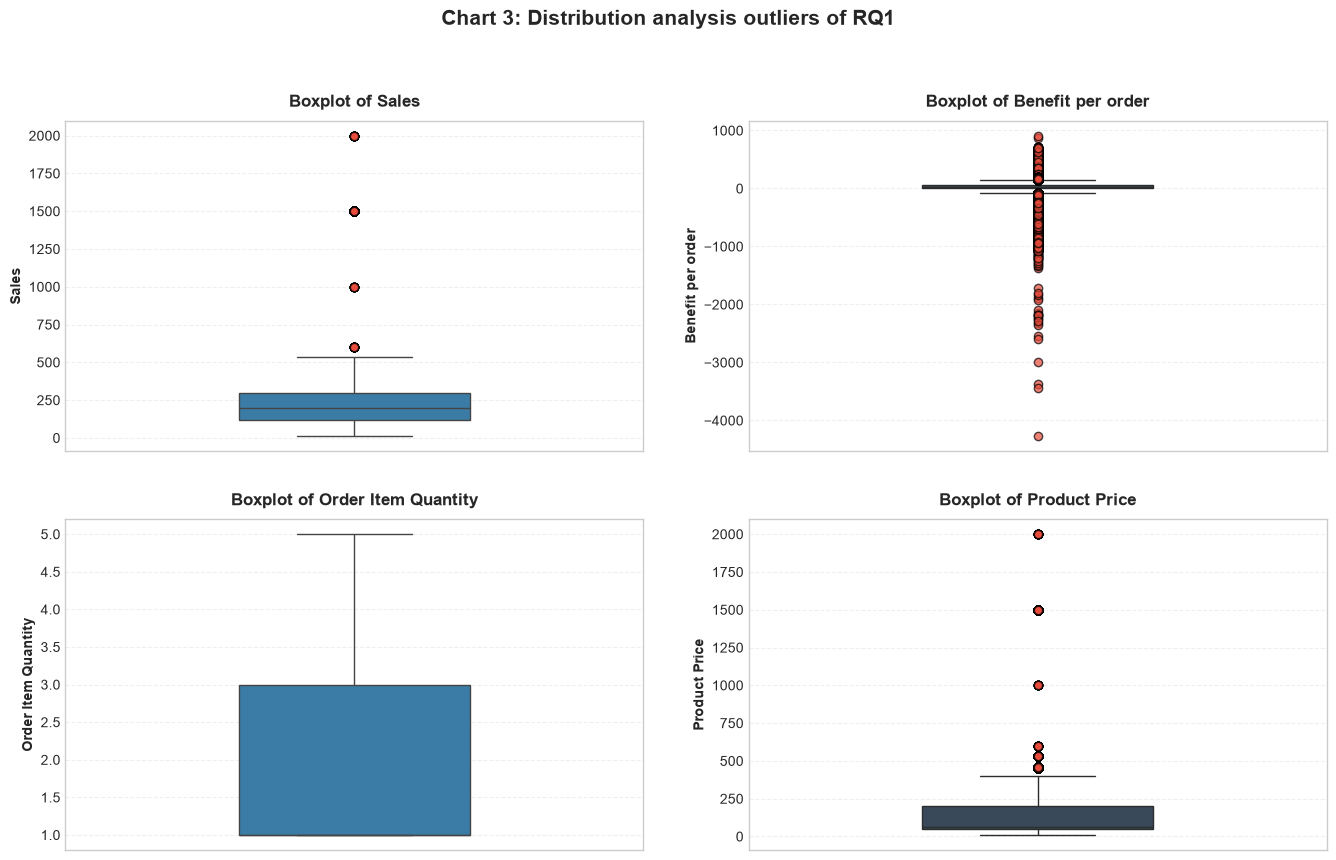

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Thiết lập kích thước biểu đồ và vẽ các Boxplots
plt.figure(figsize=(14, 9))
numerical_cols = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Product Price']

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        y=df[col],
        color='#34495e' if i % 2 == 0 else '#2980b9',
        width=0.4,
        flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=6, markeredgecolor='black', alpha=0.7)
    )
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10)
    plt.ylabel(col, fontsize=10, fontweight="bold")
    plt.grid(axis='y', alpha=0.3, linestyle='--')

# 3. Thiết lập Title tổng thể
plt.suptitle('Chart 3: Distribution analysis outliers of RQ1', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(pad=3.0)
plt.savefig('charts_img/43_rq1_boxplot_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

**INSIGHT 1:** The `Sales` and `Product Price` features exhibit an even distribution with outliers concentrated in higher ranges (> 1000 USD), representing specialized high-end items.

**INSIGHT 2:** The `Benefit per order` boxplot shows significant outliers in both the positive and negative directions (extending below -4000 USD), representing severe operational shipping losses or high penalty costs.

### 4.4. [LINK TO RQ2] - Biểu đồ 4: Scatter Plot - Khảo sát mối tương quan giữa hai biến liên tục.

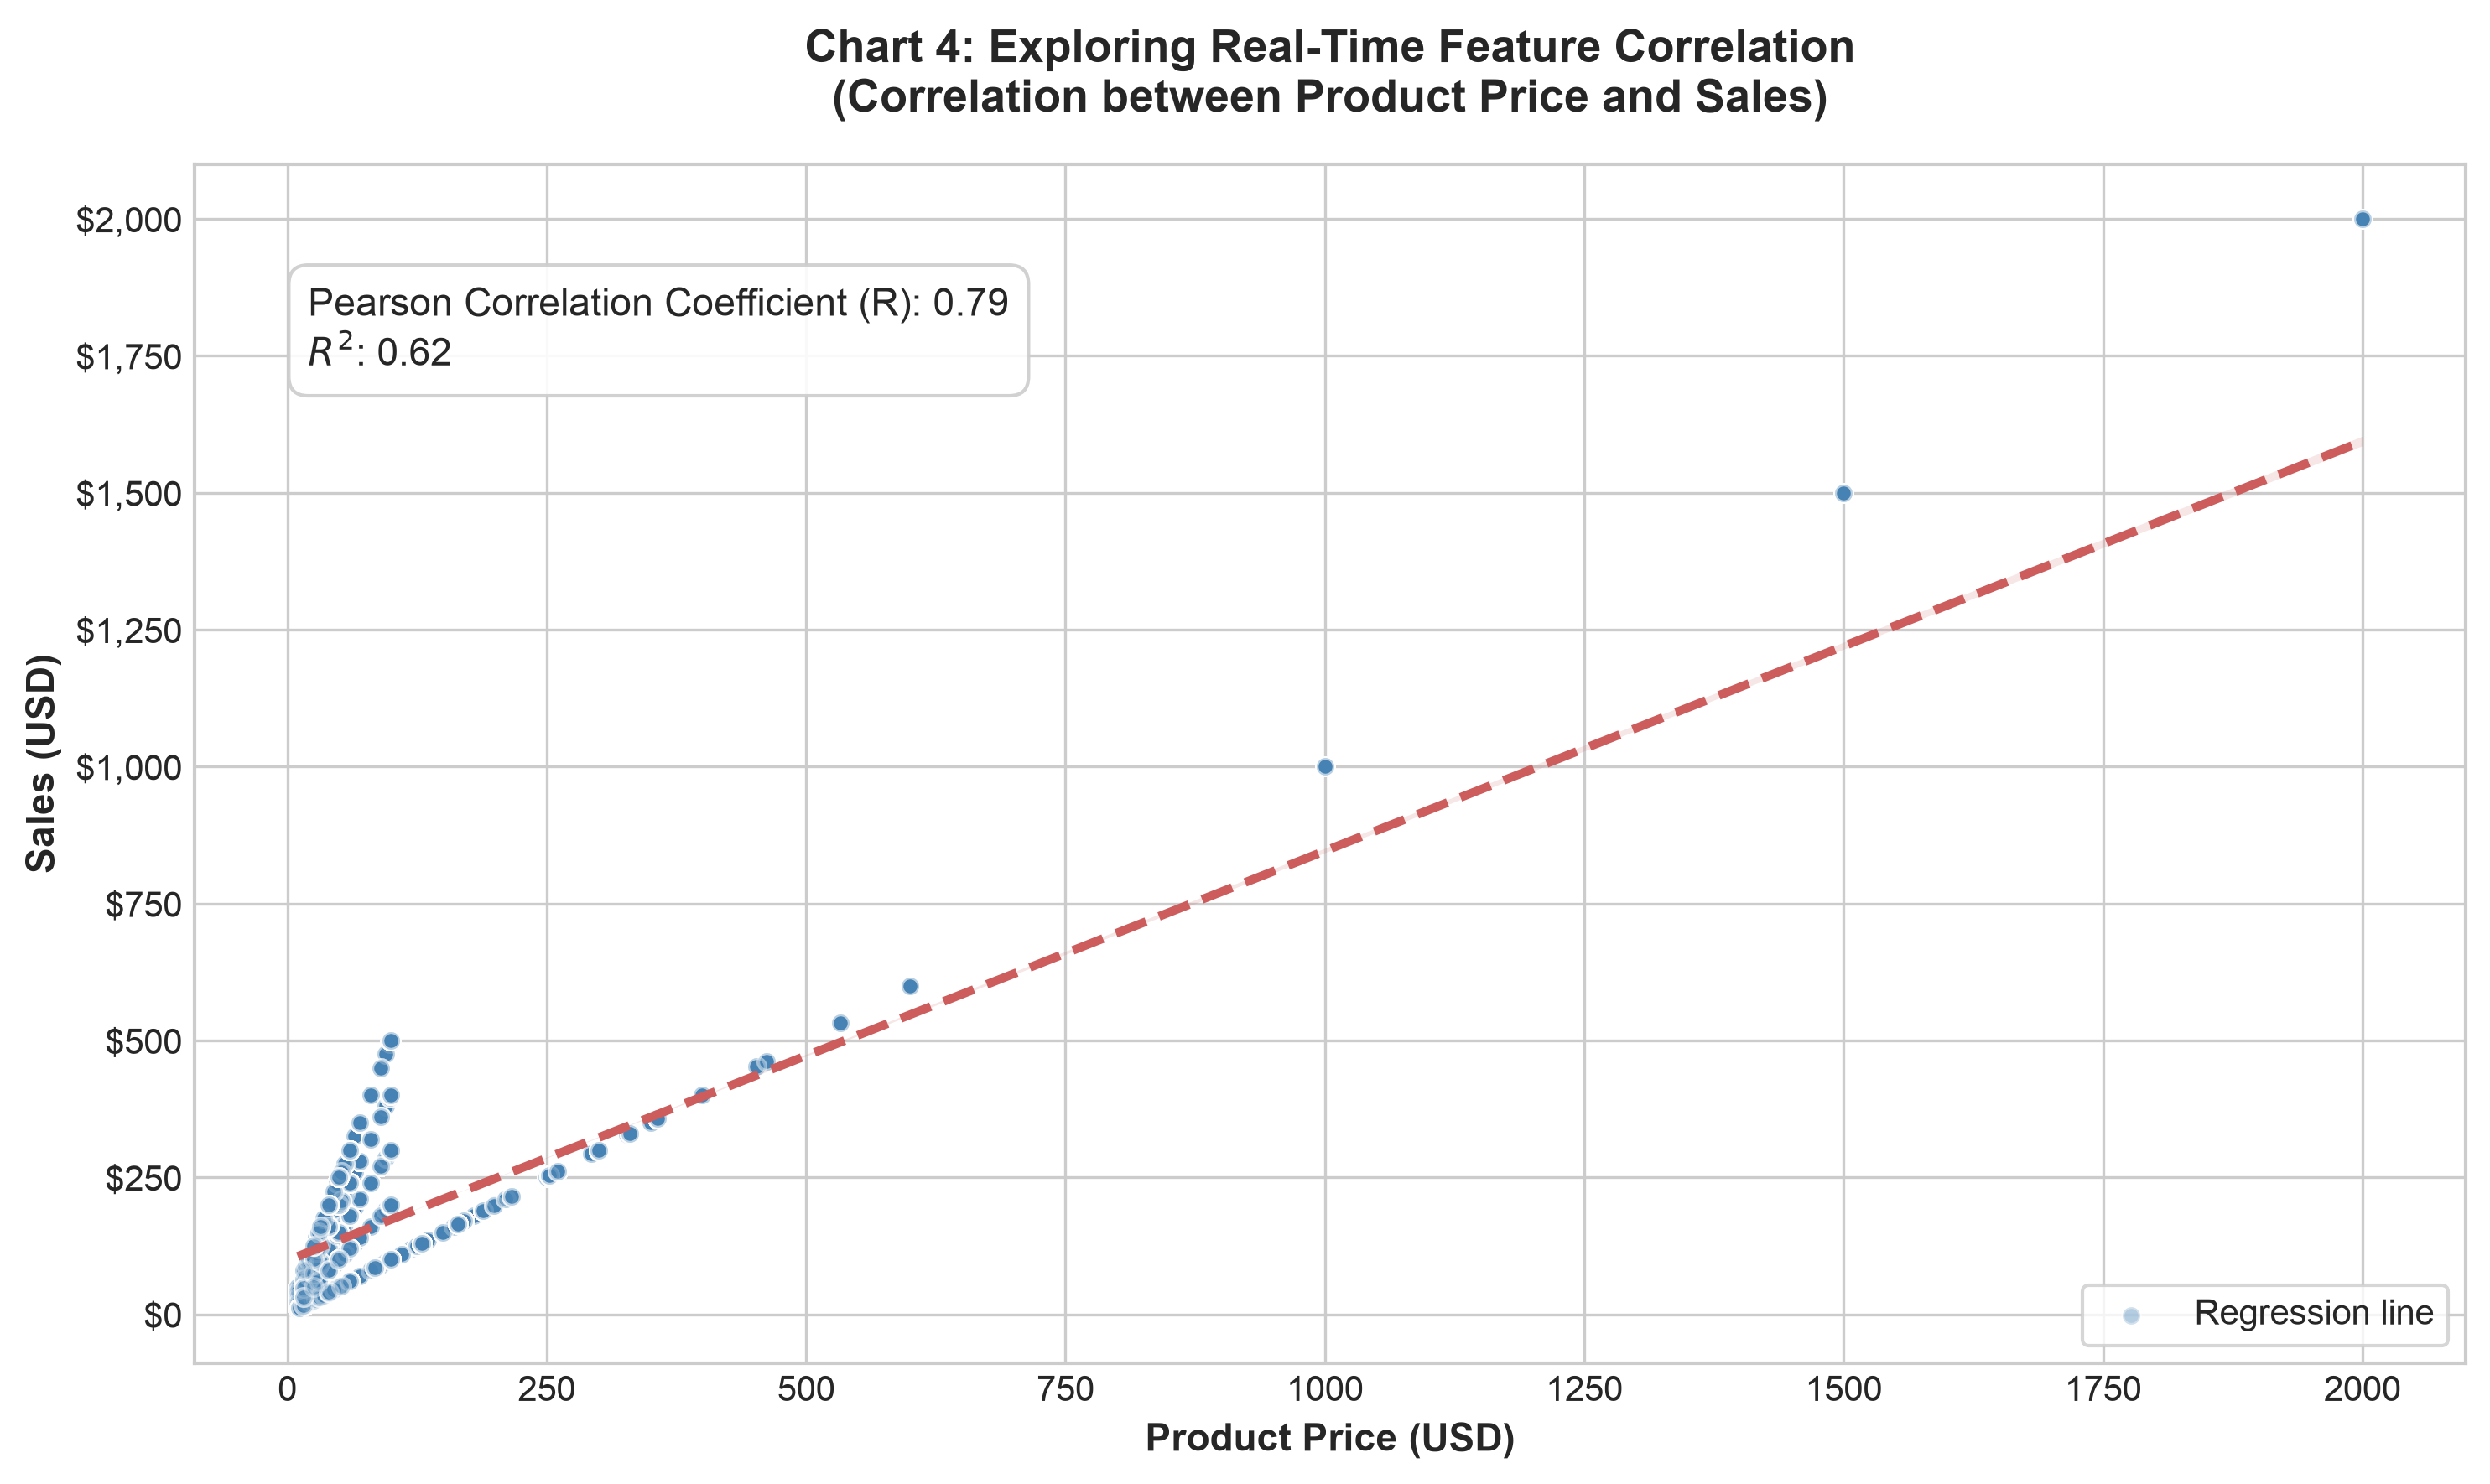

In [91]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Định nghĩa các biến số học cho biểu đồ
x_var = "Product Price"
y_var = "Sales"

# Khởi tạo khung vẽ biểu đồ với độ phân giải cao
plt.figure(figsize=(10, 6), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

# 3. Tính toán các chỉ số thống kê học thuật (Pearson R & R-squared)
r_value, _ = pearsonr(df[x_var], df[y_var])
r_squared = r_value**2

# 4. Vẽ các điểm dữ liệu (Scatter Plot) và đường hồi quy (Regression Line)
sns.regplot(
    data=df,
    x=x_var,
    y=y_var,
    scatter_kws={"alpha": 0.4, "color": "#4682B4", "edgecolors": "w", "s": 25},
    line_kws={"color": "#CD5C5C", "linestyle": "--", "linewidth": 2.5},
    label="Regression line",
)

# 5. Chèn hộp thông tin chỉ số thống kê toán học lên góc trên bên trái biểu đồ
stats_text = f"Pearson Correlation Coefficient (R): {r_value:.2f}\n$R^2$: {r_squared:.2f}"
plt.gca().text(
    0.05,
    0.90,
    stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="0.8", alpha=0.9),
)

# 6. Cấu hình tiêu đề và nhãn trục
plt.title(
    "Chart 4: Exploring Real-Time Feature Correlation\n(Correlation between Product Price and Sales)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Price (USD)", fontsize=11, fontweight="bold")
plt.ylabel("Sales (USD)", fontsize=11, fontweight="bold")

# Định dạng hiển thị tiền tệ ($) trên trục tung cho chuyên nghiệp
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${int(x):,}"))

# Thêm chú thích (Legend) và tối ưu bố cục khoảng cách biên
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()

# 7. Lưu biểu đồ ra file ảnh chất lượng cao
plt.savefig("charts_img/44_rq2_scatter_plot_correlation.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** A Pearson correlation coefficient of 0.79 confirms that `Product Price` is the dominant factor driving the final transactional `Sales` value. However, the dispersion of points around the regression line suggests that transaction modifiers, such as bulk quantity orders and discount schemes, introduce substantial variance, indicating that simple linear methods are insufficient and machine learning estimators will yield superior performance.

### 4.5. [LINK TO RQ2] - Biểu đồ 5: Heatmap Correlation  - Bản đồ nhiệt thể hiện ma trận tương quan giữa các thuộc tính.

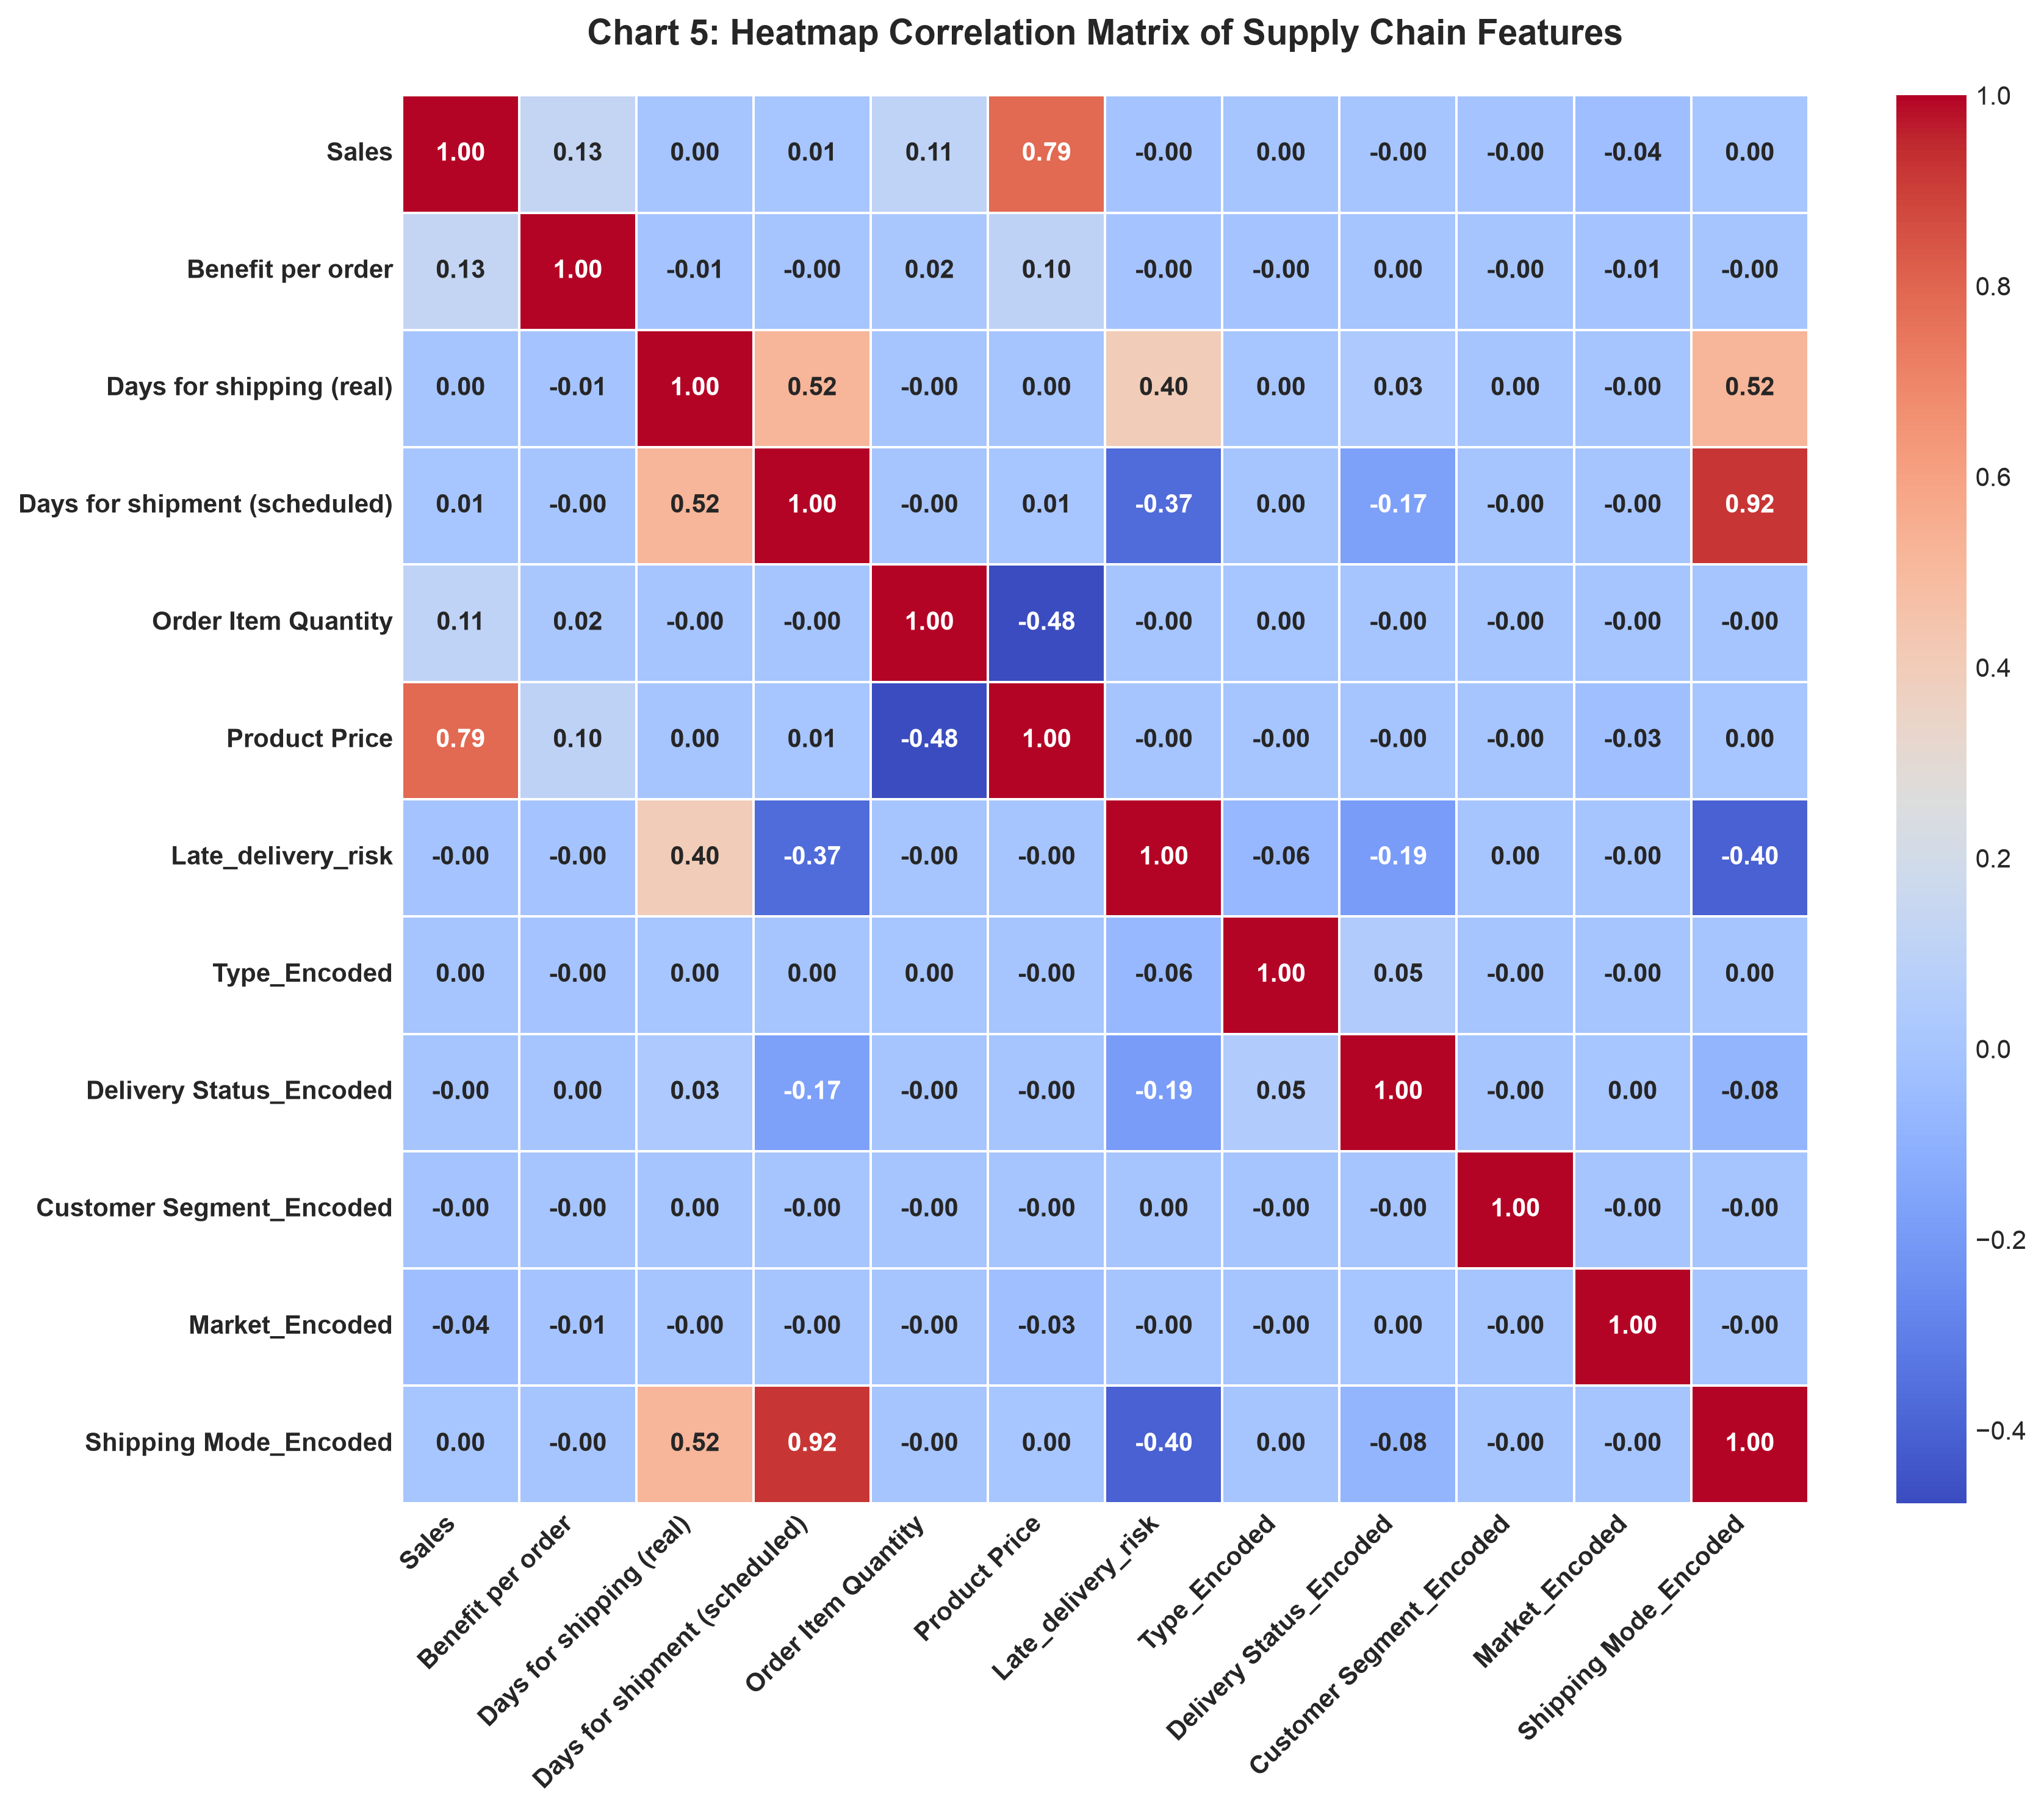

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Tính toán ma trận tương quan (Chỉ tính trên cột số quan trọng)
cols_to_corr = [
    'Sales', 'Benefit per order', 'Days for shipping (real)', 
    'Days for shipment (scheduled)', 'Order Item Quantity', 
    'Product Price', 'Late_delivery_risk', 
    'Type_Encoded', 'Delivery Status_Encoded', 
    'Customer Segment_Encoded', 'Market_Encoded', 'Shipping Mode_Encoded'
]
cols_to_corr = [c for c in cols_to_corr if c in df.columns]
corr_matrix = df[cols_to_corr].corr()

# 3. Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(12, 10), dpi=300)

# 4. Vẽ bản đồ nhiệt Heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"},
)

# 5. Cấu hình tiêu đề chuẩn hóa
plt.title(
    "Chart 5: Heatmap Correlation Matrix of Supply Chain Features",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xticks(rotation=45, ha="right", fontsize=10, fontweight="bold")
plt.yticks(rotation=0, fontsize=10, fontweight="bold")

# 6. Hiển thị biểu đồ
plt.tight_layout()
plt.savefig("charts_img/45_rq2_heatmap_correlation_matrix.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The empirical correlation matrix confirms that `Product Price` has the strongest positive linear relationship with `Sales` at 0.79, followed by `Order Item Quantity`. Delivery metrics like `Days for shipping (real)` and `Days for shipment (scheduled)` show weak correlation with transactional sales, suggesting logistics timelines operate independently of product value.

### 4.6. [LINK TO RQ2] - Biểu đồ 6: Line Chart - Biểu thị xu hướng thay đổi hoặc biến thiên của dữ liệu theo chuỗi.

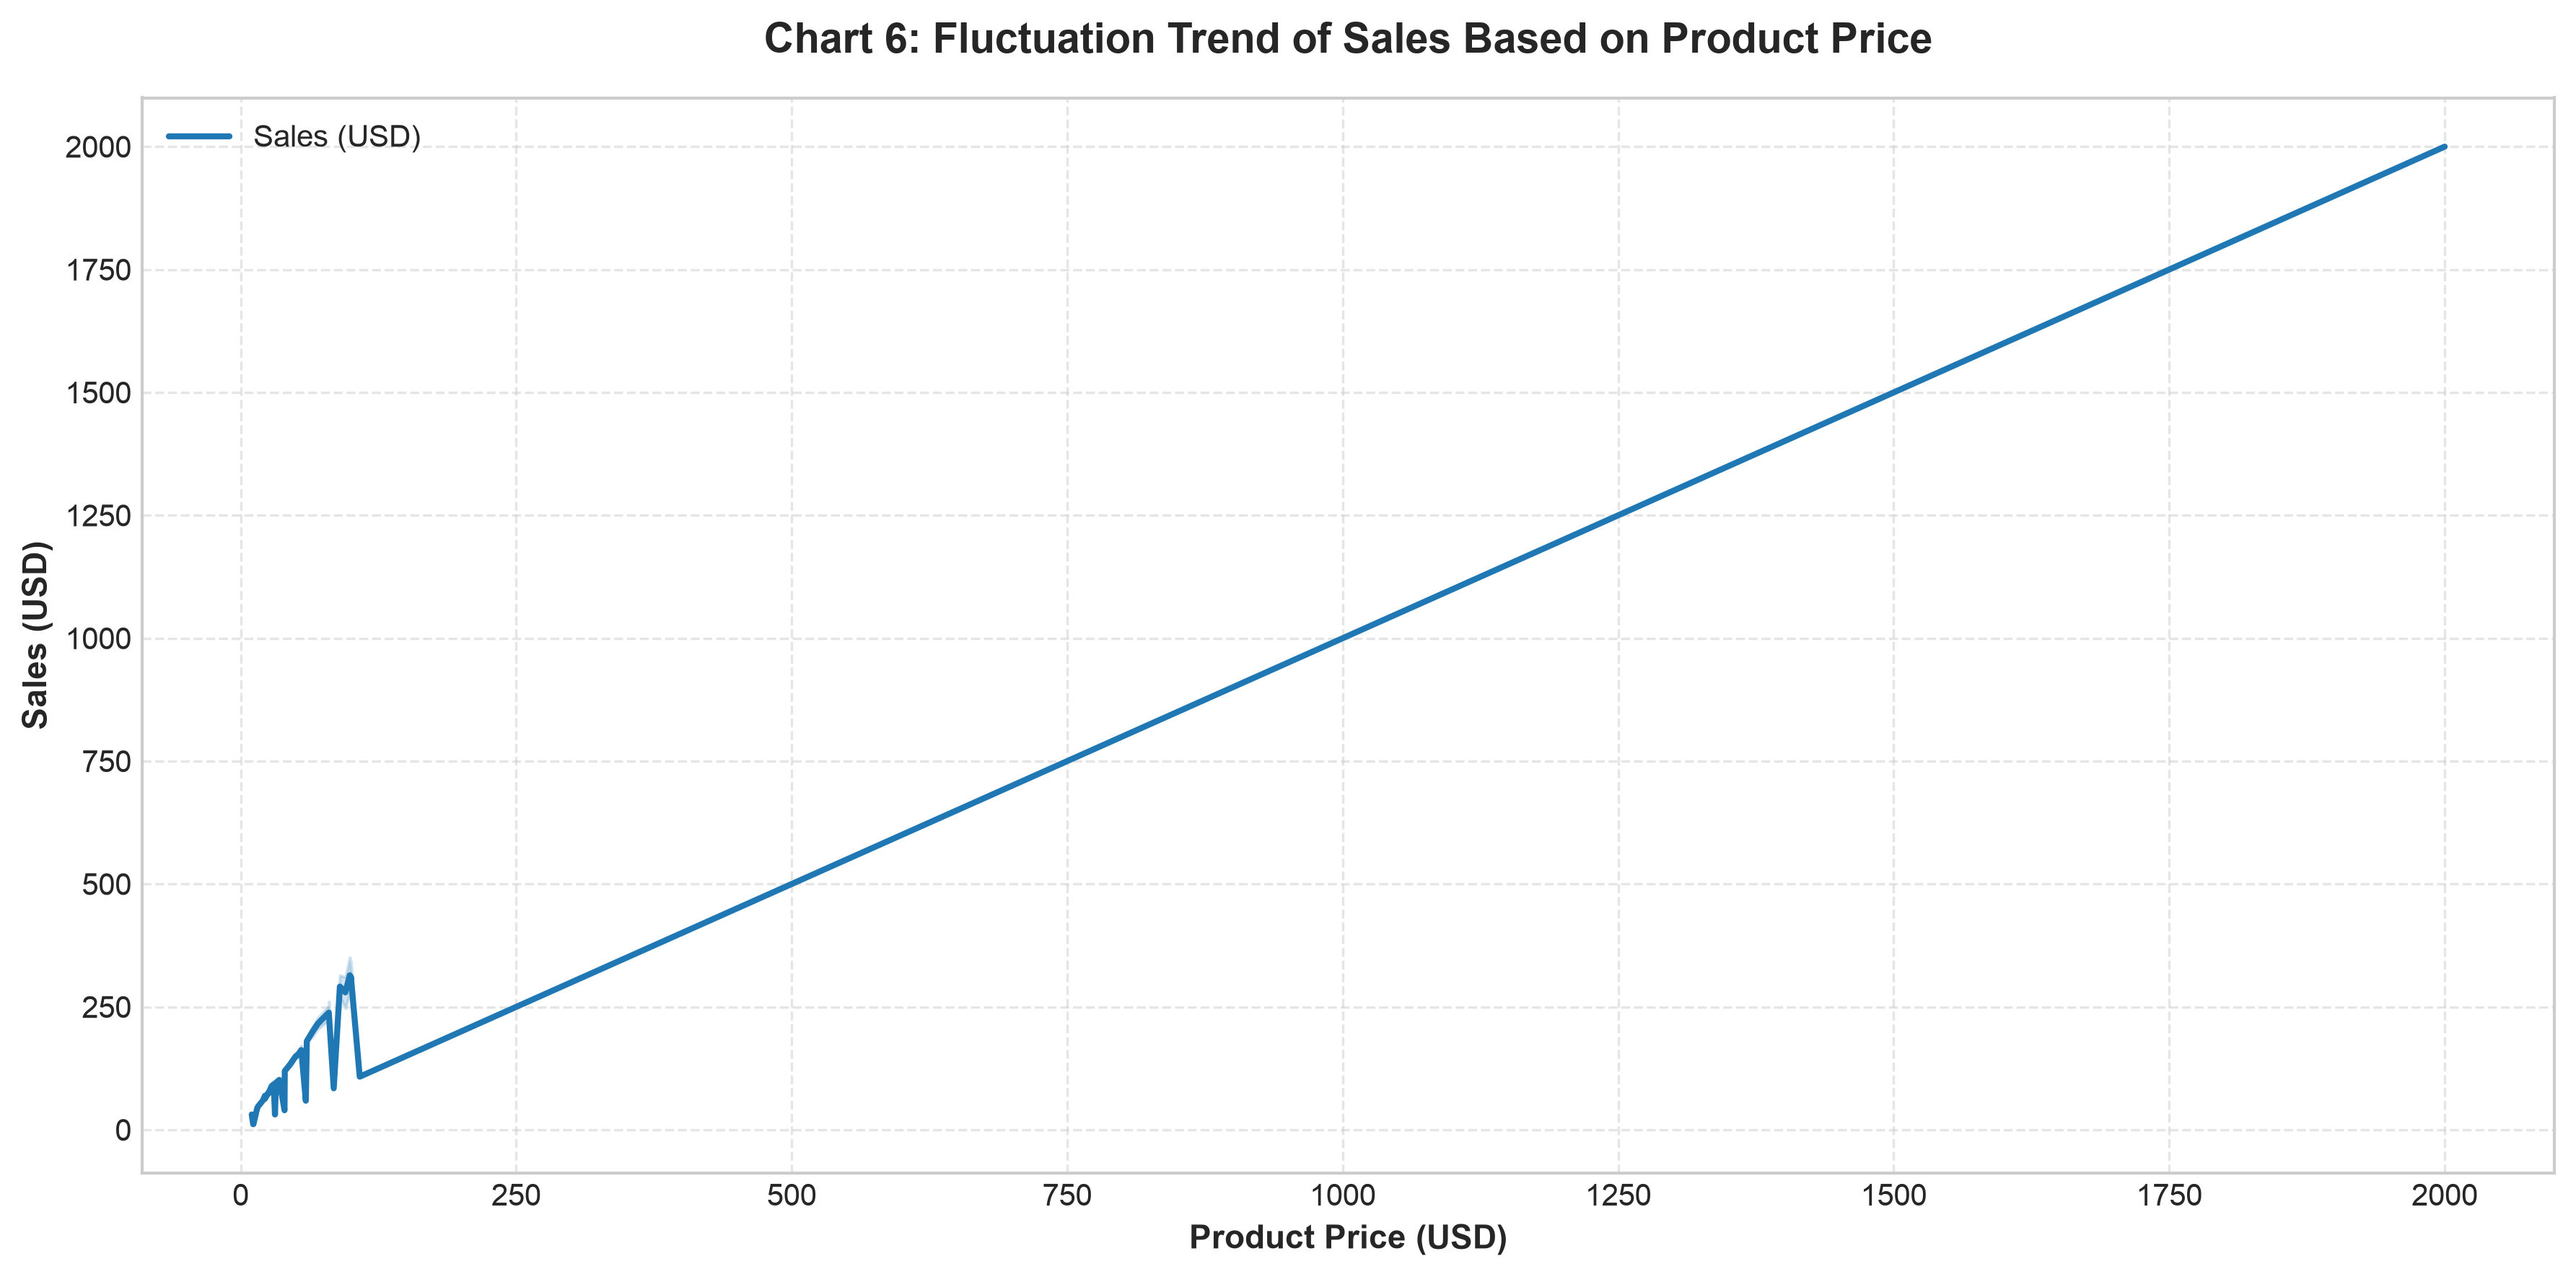

In [93]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

# 1. Kết nối database và lấy dữ liệu sạch
conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# 2. Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(12, 6), dpi=300)

# 3. Vẽ biểu đồ đường (Line Chart)
sns.lineplot(
    data=df,
    x="Product Price",
    y="Sales",
    color="#1f77b4",
    linewidth=2,
    label="Sales (USD)",
)

# 4. Cấu hình tiêu đề và nhãn
plt.title(
    "Chart 6: Fluctuation Trend of Sales Based on Product Price",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Price (USD)", fontsize=11, fontweight="bold")
plt.ylabel("Sales (USD)", fontsize=11, fontweight="bold")

# 5. Thêm lưới nền
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left")

# 6. Tối ưu khoảng cách và hiển thị
plt.tight_layout()
plt.savefig("charts_img/46_rq2_line_chart_fluctuation_trend.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The Line Chart depicts a clear positive progression of sales values corresponding to increases in product price, mirroring the correlation results. The high frequency fluctuations reflect different discount percentages and bulk quantities associated with specific product price points.

### 4.7. [LINK TO RQ3] - Biểu đồ 7: Bar Chart - Khảo sát phân bố số lượng đơn hàng theo khu vực (Market)

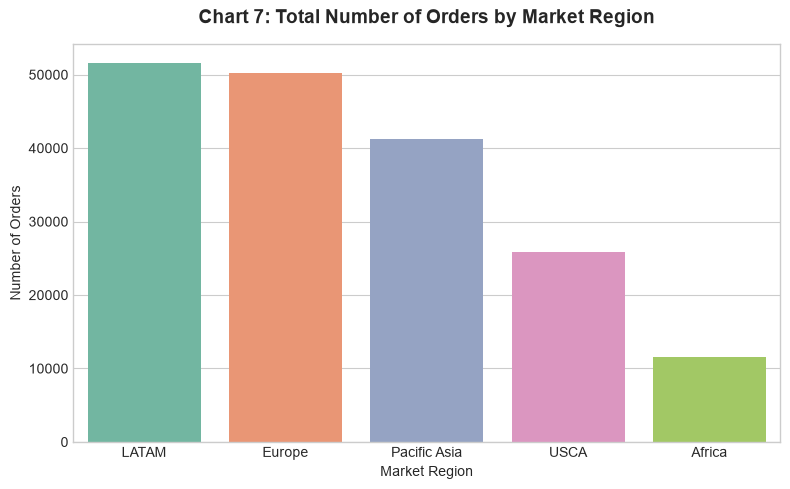

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

conn = sqlite3.connect('freight_pricing_research.db')

df_region = pd.read_sql_query("""
SELECT
    Market,
    COUNT(*) AS Total_Rides
FROM supply_chain
GROUP BY Market
ORDER BY Total_Rides DESC
""", conn)

conn.close()

plt.figure(figsize=(8,5))

sns.barplot(
    data=df_region,
    x='Market',
    y='Total_Rides',
    palette='Set2'
)
plt.title(
    'Chart 7: Total Number of Orders by Market Region',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Market Region')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.savefig("charts_img/47_rq3_bar_chart_total_number_of_rides.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** Latin America (LATAM) and Europe are the largest market segments, contributing significantly higher numbers of orders compared to the other regions.

**INSIGHT 2:** Order density is heavily skewed towards LATAM, Europe, and Pacific Asia, which accounts for the vast majority of the supply chain transaction logs, leaving USCA and Africa as smaller segments.

### 4.8. [LINK TO RQ3] - Biểu đồ 8: Boxplot - Distribution of Sales by Shipping Mode

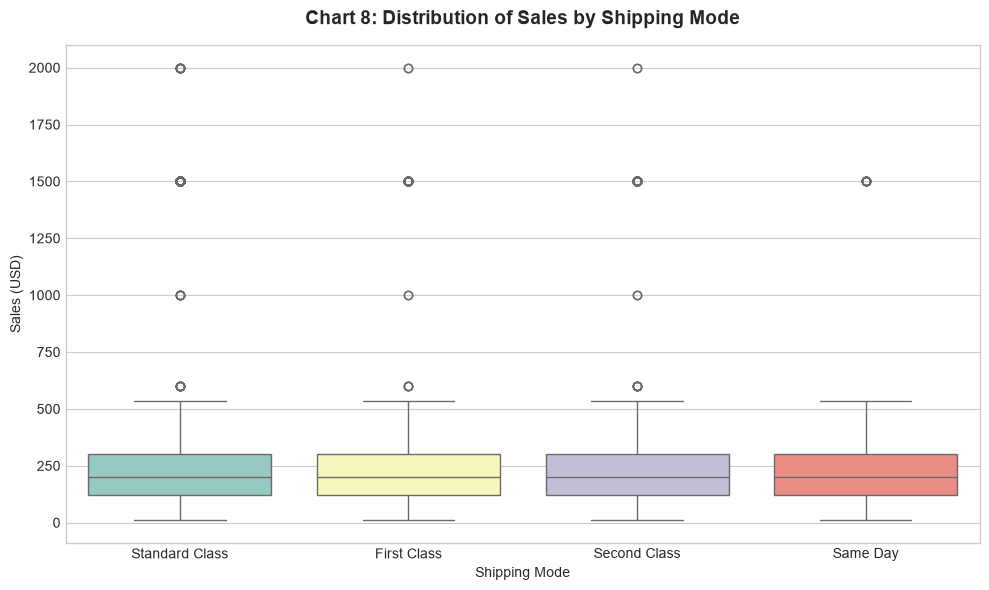

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import pandas as pd

conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Shipping Mode',
    y='Sales',
    palette='Set3'
)
plt.title(
    'Chart 8: Distribution of Sales by Shipping Mode',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Shipping Mode')
plt.ylabel('Sales (USD)')

plt.tight_layout()
plt.savefig("charts_img/48_rq3_boxplot_distribution_of_historical_cost.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The median, lower quartile, and upper quartile of sales remain consistently stable across all shipping modes, showing no major price bias based on shipping options.

**INSIGHT 2:** All shipping classes feature high-value outlier transactions exceeding 1000 USD, suggesting expensive shipments are distributed uniformly across different priority classes.

### 4.9. [LINK TO RQ3] - Biểu đồ 9: Stacked Bar Chart - Shipping Mode Composition by Customer Segment

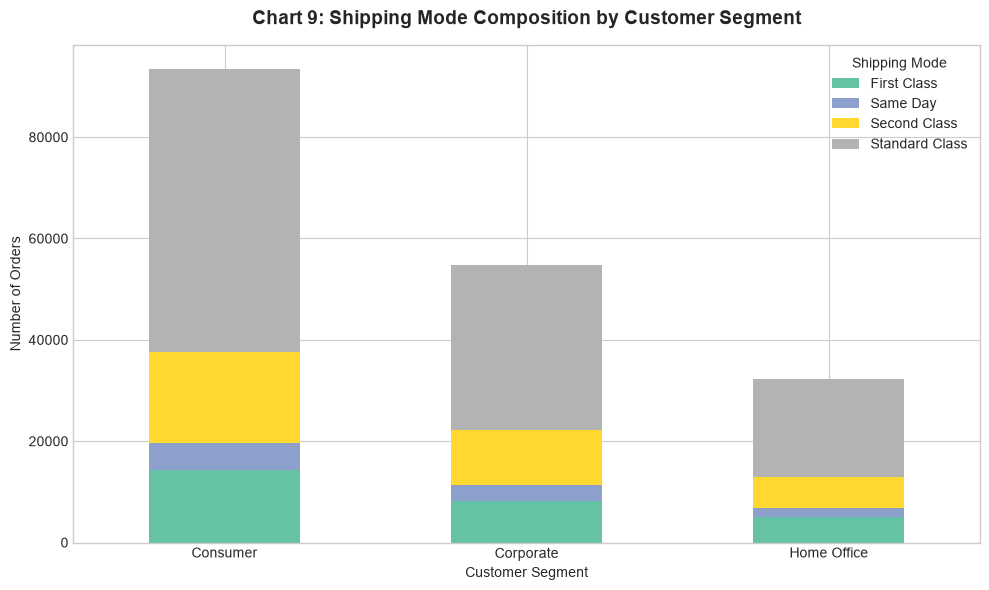

In [96]:
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

conn = sqlite3.connect('freight_pricing_research.db')
df = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

stacked_data = pd.crosstab(
    df['Customer Segment'],
    df['Shipping Mode']
)

stacked_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set2'
)
plt.title(
    'Chart 9: Shipping Mode Composition by Customer Segment',
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Orders')

plt.legend(title='Shipping Mode')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("charts_img/49_rq3_stacked_bar_chart_vehicle_type_composition.png", bbox_inches="tight", dpi=300)
plt.show()

**INSIGHT 1:** The consumer segment yields the largest overall number of orders, followed by Corporate and Home Office segments.

**INSIGHT 2:** The proportion of shipping modes is highly consistent across all customer segments, with Standard Class being the dominant shipping option chosen by all types of buyers.

## 5. Feature Engineering

### 5.0. Khởi tạo file features.csv

In [1]:
import pandas as pd
import sqlite3

# Khởi tạo file features.csv từ dữ liệu sạch trong database
conn = sqlite3.connect('freight_pricing_research.db')
df_initial = pd.read_sql_query("SELECT * FROM supply_chain", conn)
conn.close()

# Lưu thành file features.csv để các bước sau có thể đọc được
df_initial.to_csv("features.csv", index=False)
print("Successfully initialized features.csv from database.")

Successfully initialized features.csv from database.


### 5.1. FEATURE 1: Lịch sử chi tiêu theo phân khúc khách hàng & Thị trường(Market_Segment_Avg_Sales)

Mục đích: Đo lường mức chi tiêu trung bình lịch sử của từng phân khúc khách hàng (Consumer, Corporate, Home Office) tại từng Thị trường (Market). 

In [49]:
import pandas as pd

# 1. Đọc dữ liệu từ file hiện tại
df = pd.read_csv("features.csv")

# 2. Tính doanh số trung bình lịch sử theo Thị trường + Phân khúc khách hàng
segment_market_sales = df.groupby(['Market', 'Customer Segment'])['Sales'].transform('mean')
df['Market_Segment_Avg_Sales'] = segment_market_sales

# 3. Lưu và kiểm tra kết quả
df.to_csv("features.csv", index=False)
print("Feature 1: Market_Segment_Avg_Sales")
print(df[['Market', 'Customer Segment', 'Market_Segment_Avg_Sales']].head())

Feature 1: Market_Segment_Avg_Sales
         Market Customer Segment  Market_Segment_Avg_Sales
0  Pacific Asia         Consumer                201.412362
1  Pacific Asia         Consumer                201.412362
2  Pacific Asia         Consumer                201.412362
3  Pacific Asia      Home Office                197.012646
4  Pacific Asia        Corporate                201.118691


### 5.2. FEATURE 2: Mức độ giàu có / Sức mua của Thành phố(City_Historical_Sales_Level)

Mục đích: Bắt được yếu tố địa lý. Các thành phố/khu vực trung tâm có xu hướng đặt những đơn hàng tổng giá trị lớn hơn nhiều so với các khu vực nông thôn.

In [50]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv("features.csv")

# 2. Tính trung bình giá trị đơn hàng theo Thành phố đặt hàng (Order City)
city_sales = df.groupby('Order City')['Sales'].transform('mean')
df['City_Historical_Sales_Level'] = city_sales

# 3. Lưu và kiểm tra
df.to_csv("features.csv", index=False)
print("Feature 2: City_Historical_Sales_Level")
print(df[['Order City', 'City_Historical_Sales_Level']].head())

Feature 2: City_Historical_Sales_Level
   Order City  City_Historical_Sales_Level
0      Bekasi                   227.756227
1     Bikaner                   228.340005
2     Bikaner                   228.340005
3  Townsville                   201.600881
4  Townsville                   201.600881


### 5.3. FEATURE 3: Mật độ nhu cầu theo Dòng sản phẩm(Category_Market_Demand_Density)

Mục đích: Thay vì lấy giá sản phẩm, ta đo mật độ xuất hiện (tần suất đơn hàng) của dòng sản phẩm (Category Name) tại thị trường đó. Mô hình sẽ học được dòng hàng nào đang là "Hot trend" mang lại doanh thu cao.

In [61]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv("features.csv")

# 2. Đếm tổng số đơn hàng của từng Danh mục sản phẩm tại từng Thị trường
cat_density = df.groupby(['Market', 'Category Name'])['Order Id'].transform('count')
df['Category_Market_Demand_Density'] = cat_density

# 3. Lưu và kiểm tra
df.to_csv("features.csv", index=False)
print("Feature 3: Category_Market_Demand_Density")
print(df[['Market', 'Category Name', 'Category_Market_Demand_Density']].head(100))

Feature 3: Category_Market_Demand_Density
          Market    Category Name  Category_Market_Demand_Density
0   Pacific Asia   Sporting Goods                             357
1   Pacific Asia   Sporting Goods                             357
2   Pacific Asia   Sporting Goods                             357
3   Pacific Asia   Sporting Goods                             357
4   Pacific Asia   Sporting Goods                             357
..           ...              ...                             ...
95         LATAM  Women's Apparel                            6280
96         LATAM  Women's Apparel                            6280
97         LATAM    Shop By Sport                            3337
98         LATAM    Shop By Sport                            3337
99         LATAM  Women's Apparel                            6280

[100 rows x 3 columns]


### 5.4. Feature 4: Thói quen tích lũy của Khách hàng(Customer_Order_Count_History)
Đo xem đây là khách hàng mới hay khách hàng thân thiết. Khách hàng trung thành (đã đặt nhiều đơn) thường có giá trị đơn hàng trung bình cao hơn khách hàng mới.

In [71]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv("features.csv")

# 2. Đếm tổng số đơn hàng lịch sử của từng Khách hàng (Customer Id)
cust_history = df.groupby('Customer Id')['Order Id'].transform('count')
df['Customer_Order_Count_History'] = cust_history

# 3. Lưu và kiểm tra
df.to_csv("features.csv", index=False)
print("Feature 4: Customer_Order_Count_History")
print(df[['Customer Id', 'Customer_Order_Count_History']].head(80))

Feature 4: Customer_Order_Count_History
    Customer Id  Customer_Order_Count_History
0         20755                             1
1         19492                             1
2         19491                             1
3         19490                             1
4         19489                             1
..          ...                           ...
75         1025                            27
76         8831                            10
77        10679                            13
78         5007                            19
79         5007                            19

[80 rows x 2 columns]


### 5.5. Feature 5: Xu hướng doanh số theo Mùa vụ / Tháng(Monthly_Sales_Trend)
Mục đích: Doanh số bán hàng luôn có tính mùa vụ rất rõ rệt

In [70]:
import pandas as pd

# 1. Đọc dữ liệu
df = pd.read_csv("features.csv")

# 2. Xử lý thời gian và tính trung bình Doanh số theo Tháng
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['Order_Month'] = df['order date (DateOrders)'].dt.month

monthly_trend = df.groupby('Order_Month')['Sales'].transform('mean')
df['Monthly_Sales_Trend'] = monthly_trend

# 3. Lưu file hoàn tất cuối cùng
df.to_csv("features.csv", index=False)
print("Feature 5: Monthly_Sales_Trend")
print(df[['Order_Month', 'Monthly_Sales_Trend']].head(55))

Feature 5: Monthly_Sales_Trend
    Order_Month  Monthly_Sales_Trend
0             1           192.404832
1             1           192.404832
2             1           192.404832
3             1           192.404832
4             1           192.404832
5             1           192.404832
6             1           192.404832
7             1           192.404832
8             1           192.404832
9             1           192.404832
10            1           192.404832
11            1           192.404832
12            1           192.404832
13            1           192.404832
14            1           192.404832
15            1           192.404832
16            1           192.404832
17            1           192.404832
18            1           192.404832
19            1           192.404832
20            1           192.404832
21            1           192.404832
22            1           192.404832
23            1           192.404832
24            1           192.404832
25     

## 6. Train / Test Split

**Mục tiêu:** Chia dữ liệu thành 2 tập:

**- Train (80%)**: Dùng để huấn luyện mô hình AI.

**- Test (20%)**: Dùng để đánh giá hiệu suất mô hình trên dữ liệu chưa thấy.

**Lý do chọn 80/20:**
- Dataset có 180519 mẫu → cần tối đa hóa dữ liệu training.
- 20% mẫu test đủ để đánh giá độ tin cậy của kết quả sau khi training.
- `random_state=42` đảm bảo kết quả tái lập được.

### 6.1. STEP 1: LOAD THE FEATURE-ENGINEERED DATASET

In [72]:
df = pd.read_csv("features.csv")
print(f"\nTotal samples in the dataset: {df.shape[0]} rows x {df.shape[1]} columns\n")
print(f"Existing columns: {list(df.columns)}\n")


Total samples in the dataset: 180519 rows x 66 columns

Existing columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 

### 6.2. STEP 2: DROP IRRELEVANT / PII / HIGH-CARDINALITY COLUMNS

In [73]:
columns_to_drop = [
    # --- PII / Thông tin cá nhân ---
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",

    # --- ID columns (high-cardinality, no predictive value) ---
    "Order Id",
    "Customer Id",
    "Order Customer Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Category Id",
    "Product Category Id",
    "Department Id",

    # --- Text / High-cardinality categorical ---
    "Product Name",
    "Product Description",
    "Product Image",

    # --- Date columns (đã extract features ở Section 5) ---
    "order date (DateOrders)",
    "shipping date (DateOrders)",
    "Order_Date_Only",

    # --- Location columns (granular, đã có Latitude/Longitude) ---
    "Customer City",
    "Customer Country",
    "Customer State",
    "Customer Zipcode",
    "Order City",
    "Order Country",
    "Order State",
    "Order Zipcode",
    "Order Region",

    # --- Redundant categorical ---
    "Category Name", 
    "Department Name",

    # --- COLUMNS DERIVED FROM SALES (Data Leakage — PHẢI DROP) ---
    # Các cột này được TÍNH TỪ Sales, nếu giữ lại sẽ gây data leakage
    "Sales per customer",       # = Sales (leakage trực tiếp)
    "Order Item Total",         # = Sales * Quantity (derived from Sales)
    "Benefit per order",        # derived từ Sales
    "Order Profit Per Order",   # derived từ Sales
    "Order Item Profit Ratio",
    "Product Price",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Quantity",
    # === GIỮ LẠI CÁC CỘT PREDICTIVE QUAN TRỌNG ===
    # Product Price và Order Item Quantity là predictors mạnh của Sales.
    # Chúng KHÔNG phải leakage nếu dữ liệu nguyên bản chưa chứa giá trị Sales.
    # Thực tế, Sales ≈ Quantity × Price × (1 - Discount), nên cần giữ lại.
    # --- Những feature này nên được giữ trong X để cải thiện R²:
    #   - "Order Item Quantity"
    #   - "Product Price"
    #   - "Order Item Product Price"
    #   - "Order Item Discount"
    #   - "Order Item Discount Rate"
]

# Only drop columns that actually exist in the dataframe
existing_cols_to_drop = [c for c in columns_to_drop if c in df.columns]
df = df.drop(columns=existing_cols_to_drop)

print(f"Dropped {len(existing_cols_to_drop)} irrelevant/PII/high-cardinality columns.")
print(f"Remaining shape: {df.shape[0]} rows x {df.shape[1]} columns\n")
print(f"Remaining columns: {list(df.columns)}\n")


Dropped 41 irrelevant/PII/high-cardinality columns.
Remaining shape: 180519 rows x 25 columns

Remaining columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Delivery Status', 'Late_delivery_risk', 'Customer Segment', 'Latitude', 'Longitude', 'Market', 'Sales', 'Order Status', 'Product Status', 'Shipping Mode', 'Daily_Demand', 'Order_Hour', 'Is_Peak_Hour', 'Demand_Urgency', 'Customer_Segment_Encoded', 'Cancellation_Risk_Index', 'Market_Segment_Avg_Sales', 'City_Historical_Sales_Level', 'Category_Market_Demand_Density', 'Customer_Order_Count_History', 'Order_Month', 'Monthly_Sales_Trend']



### 6.3. STEP 3: SEPARATE INPUT FEATURES (x) AND TARGET VARIABLE (y)

In [74]:
# ─────────────────────────────────────────────────────────────
# STEP 3: TÁCH BIẾN ĐỘC LẬP (X) VÀ BIẾN MỤC TIÊU (y)
# ─────────────────────────────────────────────────────────────
# TARGET VARIABLE (y): Sales
#   - Đây là giá trị doanh số giao dịch mà mô hình cần DỰ ĐOÁN.
#
# INPUT FEATURES (X): Tất cả các cột còn lại
#   - Bao gồm cả cột số (numerical) và cột chữ (categorical).
#   - Encoding sẽ được thực hiện SAU KHI split ở Step 5 
#     để tránh data leakage.
# ─────────────────────────────────────────────────────────────

TARGET_COLUMN = "Sales"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print(f"Target variable (y): {TARGET_COLUMN}")
print(f"  - Min: {y.min():.2f} | Max: {y.max():.2f} | Mean: {y.mean():.2f}")
print(f"\nNumber of features (X): {X.shape[1]} columns")
print(f"  - Numerical: {X.select_dtypes(exclude=['object', 'string']).shape[1]}")
print(f"  - Categorical: {X.select_dtypes(include=['object', 'string']).shape[1]}")
print(f"\nCategorical columns (sẽ encode sau khi split):")
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()
for i, col in enumerate(cat_cols, 1):
    print(f"  {i}. {col} ({X[col].nunique()} unique values)")
print()


Target variable (y): Sales
  - Min: 9.99 | Max: 1999.99 | Mean: 203.77

Number of features (X): 24 columns
  - Numerical: 17
  - Categorical: 7

Categorical columns (sẽ encode sau khi split):
  1. Type (4 unique values)
  2. Delivery Status (4 unique values)
  3. Customer Segment (3 unique values)
  4. Market (5 unique values)
  5. Order Status (9 unique values)
  6. Shipping Mode (4 unique values)
  7. Cancellation_Risk_Index (3 unique values)



### 6.4. STEP 4: PERFORM TRAIN/TEST SPLIT

In [ ]:
# ┌─────────────────────────────────────────────────────────────────────────┐
# │  RATIONALE FOR 80/20 SPLIT (test_size=0.2)                            
# │                                                                        
# │  1. The DataCoSupplyChainDataset has ~180,000 samples — a LARGE       
# │     dataset. With this volume, both 80/20 and 70/30 would work well.  
# │     We choose 80/20 to maximize training data while retaining ~36,000 
# │     test samples for robust evaluation.                                
# │                                                                        
# │  2. 80/20 is the most widely adopted split ratio in ML:               
# │     → Recommended by Andrew Ng (Stanford) and scikit-learn docs.      
# │     → ~36,000 test samples provide highly reliable performance        
# │       estimates with narrow confidence intervals.                      
# │                                                                        
# │  3. random_state=42:                                                   
# │     → Fixes the random seed so every run produces identical splits.  
# │     → Ensures reproducibility when reporting results.                  
# │     → 42 is a popular convention (from "The Hitchhiker's Guide").     
# │                                                                        
# │    QUAN TRỌNG: Split TRƯỚC khi encode để tránh data leakage!        
# │     Encoder sẽ được fit CHỈ trên x_train ở Step 5.                   
# └─────────────────────────────────────────────────────────────────────────┘

from sklearn.model_selection import train_test_split

# --- 80/20 split ---
TEST_SIZE = 0.2    # 20% for testing
RANDOM_STATE = 42  # Fixed seed for reproducibility

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("=" * 65)
print("  TRAIN/TEST SPLIT RESULTS (80/20)")
print("=" * 65)
print(f"  Total samples          : {len(X):>6d}")
print(f"  Train set (80%)        : {x_train.shape[0]:>6d} samples x {x_train.shape[1]} features")
print(f"  Test set (20%)         : {x_test.shape[0]:>6d} samples x {x_test.shape[1]} features")
print(f"  random_state           :    {RANDOM_STATE}")
print(f"  ⚠️  Data chưa encode   : sẽ encode ở Step 5 (chỉ fit trên train)")
print("=" * 65)
print()


  TRAIN/TEST SPLIT RESULTS (80/20)
  Total samples          : 180519
  Train set (80%)        : 144415 samples x 24 features
  Test set (20%)         :  36104 samples x 24 features
  random_state           :    42
  ⚠️  Data chưa encode   : sẽ encode ở Step 5 (chỉ fit trên train)



### 6.5. STEP 5: ENCODE CATEGORICAL COLUMNS AFTER SPLITTING

In [76]:
# ─────────────────────────────────────────────────────────────
# STEP 5: ENCODE CATEGORICAL COLUMNS — FIT CHỈ TRÊN TRAIN
# ─────────────────────────────────────────────────────────────
# ⚠️ QUAN TRỌNG — TRÁNH DATA LEAKAGE:
#   - Encoder phải được FIT chỉ trên x_train
#   - Sau đó TRANSFORM cả x_train và x_test
#   - handle_unknown='ignore' để xử lý categories chỉ có trong test
# ─────────────────────────────────────────────────────────────

import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# 1. Lọc các cột categorical từ TRAINING SET
categorical_columns = x_train.select_dtypes(include=["object", "string"]).columns.tolist()
print(f"Categorical columns to encode: {categorical_columns}\n")

# 2. Khởi tạo OneHotEncoder
#   - drop='first': Tránh multicollinearity trap
#   - sparse_output=False: Trả về mảng numpy thông thường
#   - handle_unknown='ignore': Xử lý categories chỉ xuất hiện trong test
encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int, handle_unknown='ignore')

# 3. FIT encoder CHỈ trên training set (tránh data leakage!)
encoder.fit(x_train[categorical_columns])
print(f"✅ Encoder fitted on TRAINING SET only ({x_train.shape[0]} samples)")

# 4. TRANSFORM cả train và test
train_encoded = encoder.transform(x_train[categorical_columns])
test_encoded = encoder.transform(x_test[categorical_columns])

encoded_col_names = encoder.get_feature_names_out(categorical_columns)
print(f"   Generated {len(encoded_col_names)} one-hot encoded columns\n")

# 5. Tạo DataFrames từ mảng encoded
df_train_encoded = pd.DataFrame(
    train_encoded, 
    columns=encoded_col_names,
    index=x_train.index
)
df_test_encoded = pd.DataFrame(
    test_encoded, 
    columns=encoded_col_names,
    index=x_test.index
)

# 6. Lấy các cột numerical (không cần encode)
numerical_columns = x_train.select_dtypes(exclude=["object", "string"]).columns.tolist()

# 7. Ghép numerical + encoded thành DataFrames hoàn chỉnh
x_train = pd.concat([x_train[numerical_columns].reset_index(drop=True), 
                      df_train_encoded.reset_index(drop=True)], axis=1)
x_test = pd.concat([x_test[numerical_columns].reset_index(drop=True), 
                     df_test_encoded.reset_index(drop=True)], axis=1)

print(f"Final x_train shape: {x_train.shape}")
print(f"Final x_test shape:  {x_test.shape}")
print(f"\n✅ Encoding hoàn tất — KHÔNG có data leakage!")
print(f"   (Encoder chỉ fit trên train, transform cả train + test)")


Categorical columns to encode: ['Type', 'Delivery Status', 'Customer Segment', 'Market', 'Order Status', 'Shipping Mode', 'Cancellation_Risk_Index']

✅ Encoder fitted on TRAINING SET only (144415 samples)
   Generated 25 one-hot encoded columns

Final x_train shape: (144415, 42)
Final x_test shape:  (36104, 42)

✅ Encoding hoàn tất — KHÔNG có data leakage!
   (Encoder chỉ fit trên train, transform cả train + test)


### 6.5.1. STEP 5.1: FEATURE SCALING (StandardScaler)

**Feature Scaling** là bước chuẩn hóa các cột numerical về cùng scale (mean=0, std=1). Điều này quan trọng vì:

- **Ridge/Lasso Regression**: Regularization penalty phụ thuộc vào magnitude của coefficients. Nếu features có scale khác nhau, penalty sẽ không công bằng.
- **Linear Regression**: Không ảnh hưởng performance nhưng giúp interpret coefficients dễ hơn.
- **Tree-based models** (RF, XGBoost, LightGBM): Không bị ảnh hưởng bởi scaling, nhưng scaling không gây hại.

⚠️ **Fit scaler CHỈ trên training set** để tránh data leakage.

In [77]:
# ─────────────────────────────────────────────────────────────
# STEP 5.1: FEATURE SCALING — FIT CHỈ TRÊN TRAIN
# ─────────────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Xác định các cột numerical GỐC cần scale
# (KHÔNG scale one-hot encoded columns vì chúng đã là 0/1)
encoded_feature_names = list(encoder.get_feature_names_out())
cols_to_scale = [c for c in x_train.columns if c not in encoded_feature_names]

print(f"Columns to scale ({len(cols_to_scale)}):")
for i, col in enumerate(cols_to_scale, 1):
    print(f"  {i}. {col}")

# Fit scaler CHỈ trên training set
x_train[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale] = scaler.transform(x_test[cols_to_scale])

print(f"\n✅ Feature scaling hoàn tất!")
print(f"   Scaler fit trên training set ({x_train.shape[0]} samples)")
print(f"   Scaled {len(cols_to_scale)} numerical columns")
print(f"   Kept {len(encoded_feature_names)} one-hot columns unchanged")


Columns to scale (17):
  1. Days for shipping (real)
  2. Days for shipment (scheduled)
  3. Late_delivery_risk
  4. Latitude
  5. Longitude
  6. Product Status
  7. Daily_Demand
  8. Order_Hour
  9. Is_Peak_Hour
  10. Demand_Urgency
  11. Customer_Segment_Encoded
  12. Market_Segment_Avg_Sales
  13. City_Historical_Sales_Level
  14. Category_Market_Demand_Density
  15. Customer_Order_Count_History
  16. Order_Month
  17. Monthly_Sales_Trend

✅ Feature scaling hoàn tất!
   Scaler fit trên training set (144415 samples)
   Scaled 17 numerical columns
   Kept 25 one-hot columns unchanged


### 6.6. STEP 6: VERIFY DISTRIBUTION AFTER SPLITTING

In [78]:
# REASON: We need to ensure the distribution of Sales in Train and Test sets
# is similar. If the distributions diverge significantly, the model will learn
# incorrect patterns and evaluation metrics will be unreliable.

print("DISTRIBUTION CHECK — TARGET VARIABLE (Sales):")
print("-" * 55)
print(f"  {'Statistic':<20s} {'Overall':>10s} {'Train':>10s} {'Test':>10s}")
print("-" * 55)
print(f"  {'Count':<20s} {len(y):>10d} {len(y_train):>10d} {len(y_test):>10d}")
print(f"  {'Mean':<20s} {y.mean():>10.2f} {y_train.mean():>10.2f} {y_test.mean():>10.2f}")
print(f"  {'Median':<20s} {y.median():>10.2f} {y_train.median():>10.2f} {y_test.median():>10.2f}")
print(f"  {'Std Dev':<20s} {y.std():>10.2f} {y_train.std():>10.2f} {y_test.std():>10.2f}")
print(f"  {'Min':<20s} {y.min():>10.2f} {y_train.min():>10.2f} {y_test.min():>10.2f}")
print(f"  {'Max':<20s} {y.max():>10.2f} {y_train.max():>10.2f} {y_test.max():>10.2f}")
print("-" * 55)
print()

# Check the mean difference between Train and Test
mean_diff = abs(y_train.mean() - y_test.mean())
mean_diff_pct = mean_diff / y.mean() * 100
print(f"  → Mean difference between Train and Test: {mean_diff:.2f} ({mean_diff_pct:.2f}%)")
if mean_diff_pct < 5:
    print("✅ Distributions are SIMILAR — data was split properly!")
else:
    print("⚠️ Distributions differ — consider using a stratified split.")
print()

DISTRIBUTION CHECK — TARGET VARIABLE (Sales):
-------------------------------------------------------
  Statistic               Overall      Train       Test
-------------------------------------------------------
  Count                    180519     144415      36104
  Mean                     203.77     203.53     204.75


  Median                   199.92     199.92     199.92
  Std Dev                  132.27     132.42     131.69
  Min                        9.99       9.99       9.99
  Max                     1999.99    1999.99    1999.99
-------------------------------------------------------

  → Mean difference between Train and Test: 1.22 (0.60%)
✅ Distributions are SIMILAR — data was split properly!



### 6.7. STEP 7: CONFIRM DATA IS READY FOR MODEL TRAINING

In [79]:
# Check for NaN values
nan_in_x_train = x_train.isnull().sum().sum()
nan_in_x_test = x_test.isnull().sum().sum()
nan_in_y = y_train.isnull().sum() + y_test.isnull().sum()

print(f"  NaN values in x_train  : {nan_in_x_train}")
print(f"  NaN values in x_test   : {nan_in_x_test}")
print(f"  NaN values in y        : {nan_in_y}")

# Check data types
non_numeric = x_train.select_dtypes(exclude=["number"]).columns.tolist()
if len(non_numeric) == 0:
    print(f"  Data type of x         : ✅ All numeric")
else:
    print(f"  Data type of x         : ⚠️  Non-numeric columns remain: {non_numeric}")

# Check data leakage
print(f"  Data leakage check     : ✅ Target '{TARGET_COLUMN}' has been excluded from x")
print("-" * 55)
print()

# Final summary
print("╔═══════════════════════════════════════════════════════════════╗")
print("║          VARIABLES READY FOR TRAINING:                       ")
print("║                                                               ")
print(f"║   x_train : ({x_train.shape[0]}, {x_train.shape[1]})  — Training features")
print(f"║   x_test  : ({x_test.shape[0]}, {x_test.shape[1]})  — Test features")
print(f"║   y_train : ({len(y_train)},)      — Training target (Sales)")
print(f"║   y_test  : ({len(y_test)},)      — Test target (Sales)")
print("║                                                                ")
print("║   → Proceed to Section 7: Training Machine Learning Models")
print("╚═══════════════════════════════════════════════════════════════╝")

  NaN values in x_train  : 0
  NaN values in x_test   : 0
  NaN values in y        : 0
  Data type of x         : ✅ All numeric
  Data leakage check     : ✅ Target 'Sales' has been excluded from x
-------------------------------------------------------

╔═══════════════════════════════════════════════════════════════╗
║          VARIABLES READY FOR TRAINING:                       
║                                                               
║   x_train : (144415, 42)  — Training features
║   x_test  : (36104, 42)  — Test features
║   y_train : (144415,)      — Training target (Sales)
║   y_test  : (36104,)      — Test target (Sales)
║                                                                
║   → Proceed to Section 7: Training Machine Learning Models
╚═══════════════════════════════════════════════════════════════╝


## 7. Training Machine Learning Models

Trong phần này, nhóm sẽ huấn luyện **6 mô hình Machine Learning** để dự đoán biến mục tiêu `Sales` (giá bán / doanh số) — phục vụ cho bài toán **AI-Driven Dynamic Pricing** trong lĩnh vực Freight & Shipping Logistics.

### Danh sách mô hình:

| # | Mô hình | Loại | Đặc điểm chính |
|----|---------|------|----------------|
| 1 | **Linear Regression** | Tuyến tính | Baseline đơn giản, giả định quan hệ tuyến tính giữa features và target |
| 2 | **Ridge Regression** | Tuyến tính + Regularization (L2) | Giảm overfitting bằng penalty L2, phù hợp khi có nhiều features tương quan |
| 3 | **Lasso Regression** | Tuyến tính + Regularization (L1) | Tự động loại bỏ features kém quan trọng (feature selection tự động) |
| 4 | **Random Forest** | Ensemble (Bagging) | Kết hợp nhiều Decision Trees, ổn định, ít bị overfitting |
| 5 | **XGBoost** | Ensemble (Boosting) | Gradient Boosting tối ưu, hiệu suất cao trên dữ liệu dạng bảng |
| 6 | **LightGBM** | Ensemble (Boosting) | Tốc độ nhanh, hiệu quả với dataset lớn, sử dụng leaf-wise growth |

### Metrics đánh giá:
- **MAE** (Mean Absolute Error): Sai số tuyệt đối trung bình — dễ diễn giải.
- **RMSE** (Root Mean Squared Error): Phạt mạnh các sai số lớn.
- **R² Score**: Tỷ lệ phương sai được giải thích bởi mô hình (1.0 = hoàn hảo).

### Dữ liệu đầu vào:
- Sử dụng `x_train`, `x_test`, `y_train`, `y_test` đã được chuẩn bị ở **Mục 6**.
- Tất cả features đã được One-Hot Encoded, không còn giá trị NaN.

### 7.0. Import thư viện & Chuẩn bị hàm đánh giá chung

Trước khi huấn luyện, nhóm import toàn bộ thư viện cần thiết và định nghĩa hàm `evaluate_model()` dùng chung cho tất cả mô hình — đảm bảo tính nhất quán khi so sánh kết quả.

In [80]:
# ============================================================
# 7.0 — IMPORT LIBRARIES & DEFINE EVALUATION FUNCTION
# ============================================================

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sklearn — Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

# Sklearn — Metrics & Cross-Validation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Gradient Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

# --------------------------------------------------
# Hàm đánh giá chung cho tất cả mô hình
# (Đã thêm 5-fold Cross-Validation)
# --------------------------------------------------
# Dictionary lưu kết quả tất cả mô hình để so sánh ở cuối
all_results = {}

def evaluate_model(model_name, model, x_train, x_test, y_train, y_test):
    """
    Huấn luyện mô hình, dự đoán, tính metrics, thực hiện CV, và lưu kết quả.
    
    Parameters:
        model_name (str): Tên mô hình (dùng làm key trong dict kết quả)
        model: Đối tượng mô hình sklearn/xgboost/lightgbm
        x_train, x_test: Features train/test
        y_train, y_test: Target train/test
    
    Returns:
        dict: Kết quả gồm MAE, RMSE, R², CV scores, thời gian huấn luyện
    """
    print(f"{'='*65}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*65}")
    
    # --- Huấn luyện ---
    start_time = time.time()
    model.fit(x_train, y_train)
    train_time = time.time() - start_time
    
    # --- Dự đoán ---
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    
    # --- Tính Metrics trên TEST SET ---
    mae  = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    
    # --- Tính R² trên TRAIN SET (kiểm tra overfitting) ---
    r2_train = r2_score(y_train, y_pred_train)
    
    # --- 5-Fold Cross-Validation ---
    print(f"\n  ⏳ Running 5-fold Cross-Validation...")
    cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # --- In kết quả ---
    print(f"\n     Training time     : {train_time:.2f} seconds")
    print(f"  ─────────────────────────────────────────")
    print(f"    TEST SET METRICS:")
    print(f"     MAE  (Mean Absolute Error)    : {mae:>12.4f}")
    print(f"     RMSE (Root Mean Squared Error): {rmse:>12.4f}")
    print(f"     R² Score                      : {r2:>12.4f}")
    print(f"  ─────────────────────────────────────────")
    print(f"    5-FOLD CROSS-VALIDATION:")
    print(f"     CV R² scores : {[f'{s:.4f}' for s in cv_scores]}")
    print(f"     Mean CV R²   : {cv_mean:.4f} ± {cv_std:.4f}")
    print(f"  ─────────────────────────────────────────")
    print(f"  🔍 OVERFITTING CHECK:")
    print(f"     R² (Train) : {r2_train:.4f}")
    print(f"     R² (Test)  : {r2:.4f}")
    gap = abs(r2_train - r2)
    if gap < 0.05:
        print(f"     → Gap: {gap:.4f} — ✅ No significant overfitting")
    elif gap < 0.10:
        print(f"     → Gap: {gap:.4f} — ⚠️ Mild overfitting detected")
    else:
        print(f"     → Gap: {gap:.4f} — 🔴 Significant overfitting!")
    print(f"{'='*65}\n")
    
    # --- Lưu kết quả ---
    result = {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2_Score': r2,
        'R2_Train': r2_train,
        'CV_R2_Mean': round(cv_mean, 4),
        'CV_R2_Std': round(cv_std, 4),
        'Train_Time_s': round(train_time, 2),
    }
    all_results[model_name] = result
    
    return result

print("✅ Thư viện đã được import và hàm evaluate_model() đã sẵn sàng.")
print(f"   (Đã tích hợp 5-fold Cross-Validation)")
print(f"x_train: {x_train.shape} | x_test: {x_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")


✅ Thư viện đã được import và hàm evaluate_model() đã sẵn sàng.
   (Đã tích hợp 5-fold Cross-Validation)
x_train: (144415, 42) | x_test: (36104, 42)
y_train: (144415,) | y_test: (36104,)


### 7.1. Model 1: Linear Regression (Hồi quy tuyến tính)

**Linear Regression** là mô hình cơ bản nhất trong ML, được sử dụng làm **baseline** để so sánh với các mô hình phức tạp hơn.

**Công thức:**
$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

**Ưu điểm:**
- Đơn giản, dễ diễn giải
- Huấn luyện nhanh
- Cho phép hiểu rõ ảnh hưởng (hệ số) của từng feature

**Nhược điểm:**
- Giả định quan hệ tuyến tính giữa features và target
- Nhạy cảm với outliers và multicollinearity

**Lý do chọn:** Là mô hình baseline bắt buộc — nếu các mô hình phức tạp không vượt qua được Linear Regression, chúng không đáng sử dụng.

In [81]:
# ============================================================
# 7.1 — LINEAR REGRESSION
# ============================================================

lr_model = LinearRegression()

lr_result = evaluate_model(
    model_name='Linear Regression',
    model=lr_model,
    x_train=x_train, x_test=x_test,
    y_train=y_train, y_test=y_test
)

# Hiển thị Top 10 features có hệ số (coefficient) lớn nhất
coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

print("Top 10 Features has the greatest influence (with coefficient):")
print(coef_df.to_string(index=False))

  MODEL: Linear Regression

  ⏳ Running 5-fold Cross-Validation...

     Training time     : 0.54 seconds
  ─────────────────────────────────────────
    TEST SET METRICS:
     MAE  (Mean Absolute Error)    :      95.4869
     RMSE (Root Mean Squared Error):     128.1691
     R² Score                      :       0.0527
  ─────────────────────────────────────────
    5-FOLD CROSS-VALIDATION:
     CV R² scores : ['0.0569', '0.0381', '0.0642', '0.0613', '0.0612']
     Mean CV R²   : 0.0563 ± 0.0094
  ─────────────────────────────────────────
  🔍 OVERFITTING CHECK:
     R² (Train) : 0.0574
     R² (Test)  : 0.0527
     → Gap: 0.0047 — ✅ No significant overfitting

Top 10 Features has the greatest influence (with coefficient):
                       Feature  Coefficient
                  Market_LATAM    27.942986
   City_Historical_Sales_Level    22.440010
                   Market_USCA    16.534825
                  Daily_Demand   -13.025539
Category_Market_Demand_Density    -9.327203
   

### 7.2. Model 2: Ridge Regression (Hồi quy Ridge — L2 Regularization)

**Ridge Regression** là phiên bản cải tiến của Linear Regression, thêm **penalty L2** để giảm overfitting.

**Công thức Loss:**
$$\text{Loss} = \sum(y_i - \hat{y}_i)^2 + \alpha \sum \beta_j^2$$

- $\alpha$ (alpha): Hệ số regularization — giá trị càng lớn, mô hình càng đơn giản.

**Ưu điểm:**
- Giảm overfitting so với Linear Regression
- Xử lý tốt khi nhiều features có tương quan cao (multicollinearity)
- Giữ lại tất cả features (không loại bỏ feature nào)

**Nhược điểm:**
- Vẫn giả định quan hệ tuyến tính
- Không thực hiện feature selection tự động

**Lý do chọn:** Dataset sau One-Hot Encoding có nhiều features tương quan → Ridge giúp ổn định các hệ số.

In [82]:
# ============================================================
# 7.2 — RIDGE REGRESSION (L2 Regularization)
# ============================================================

# alpha=1.0 là giá trị mặc định, tạo cân bằng giữa fitting và regularization
ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_result = evaluate_model(
    model_name='Ridge Regression',
    model=ridge_model,
    x_train=x_train, x_test=x_test,
    y_train=y_train, y_test=y_test
)

# So sánh nhanh với Linear Regression
print("Quick comparison of Ridge and Linear Regression:")
print(f"   Linear Regression R²: {all_results['Linear Regression']['R2_Score']:.4f}")
print(f"   Ridge Regression  R²: {ridge_result['R2_Score']:.4f}")
diff = ridge_result['R2_Score'] - all_results['Linear Regression']['R2_Score']
print(f"   → Difference: {diff:+.4f}")

  MODEL: Ridge Regression

  ⏳ Running 5-fold Cross-Validation...

     Training time     : 0.10 seconds
  ─────────────────────────────────────────
    TEST SET METRICS:
     MAE  (Mean Absolute Error)    :      95.4869
     RMSE (Root Mean Squared Error):     128.1691
     R² Score                      :       0.0527
  ─────────────────────────────────────────
    5-FOLD CROSS-VALIDATION:
     CV R² scores : ['0.0569', '0.0381', '0.0642', '0.0613', '0.0612']
     Mean CV R²   : 0.0563 ± 0.0094
  ─────────────────────────────────────────
  🔍 OVERFITTING CHECK:
     R² (Train) : 0.0574
     R² (Test)  : 0.0527
     → Gap: 0.0047 — ✅ No significant overfitting

Quick comparison of Ridge and Linear Regression:
   Linear Regression R²: 0.0527
   Ridge Regression  R²: 0.0527
   → Difference: +0.0000


### 7.3. Model 3: Lasso Regression (L1 Regularization)

**Lasso Regression** sử dụng **penalty L1**, có khả năng đặc biệt: **tự động loại bỏ features kém quan trọng** bằng cách đẩy hệ số của chúng về 0.

**Công thức Loss:**
$$\text{Loss} = \sum(y_i - \hat{y}_i)^2 + \alpha \sum |\beta_j|$$

**Ưu điểm:**
- Thực hiện **feature selection tự động** — loại bỏ features không cần thiết
- Tạo mô hình sparse (thưa) — dễ diễn giải hơn
- Giảm overfitting hiệu quả

**Nhược điểm:**
- Có thể loại bỏ features quan trọng nếu alpha quá lớn
- Không ổn định khi features có tương quan cao (chọn ngẫu nhiên 1 trong nhóm)

**Lý do chọn:** Giúp xác định features nào thực sự quan trọng cho Dynamic Pricing — hỗ trợ ra quyết định kinh doanh.

In [83]:
# ============================================================
# 7.3 — LASSO REGRESSION (L1 Regularization)
# ============================================================

# alpha=0.1: Giá trị vừa phải để không loại bỏ quá nhiều features
# max_iter=10000: Đảm bảo convergence với dataset lớn
lasso_model = Lasso(alpha=0.1, max_iter=10000, random_state=42)

lasso_result = evaluate_model(
    model_name='Lasso Regression',
    model=lasso_model,
    x_train=x_train, x_test=x_test,
    y_train=y_train, y_test=y_test
)

# Phân tích feature selection của Lasso
lasso_coefs = pd.Series(lasso_model.coef_, index=x_train.columns)
n_zero = (lasso_coefs == 0).sum()
n_nonzero = (lasso_coefs != 0).sum()
print(f"Lasso Feature Selection:")
print(f"   Total features      : {len(lasso_coefs)}")
print(f"   Keep Features    : {n_nonzero} (coefficient ≠ 0)")
print(f"   Remove Features    : {n_zero} (coefficient = 0)")
print(f"\n   Top 10 Important Features (with coefficient):")
top_lasso = lasso_coefs.abs().sort_values(ascending=False).head(10)
for feat, coef in top_lasso.items():
    print(f"     {feat:<40s} : {lasso_coefs[feat]:>10.4f}")

  MODEL: Lasso Regression

  ⏳ Running 5-fold Cross-Validation...

     Training time     : 0.44 seconds
  ─────────────────────────────────────────
    TEST SET METRICS:
     MAE  (Mean Absolute Error)    :      95.4720
     RMSE (Root Mean Squared Error):     128.1594
     R² Score                      :       0.0528
  ─────────────────────────────────────────
    5-FOLD CROSS-VALIDATION:
     CV R² scores : ['0.0569', '0.0384', '0.0639', '0.0613', '0.0612']
     Mean CV R²   : 0.0563 ± 0.0092
  ─────────────────────────────────────────
  🔍 OVERFITTING CHECK:
     R² (Train) : 0.0572
     R² (Test)  : 0.0528
     → Gap: 0.0044 — ✅ No significant overfitting

Lasso Feature Selection:
   Total features      : 42
   Keep Features    : 21 (coefficient ≠ 0)
   Remove Features    : 21 (coefficient = 0)

   Top 10 Important Features (with coefficient):
     Market_LATAM                             :    22.7817
     City_Historical_Sales_Level              :    22.3904
     Daily_Demand     

### 7.4. Model 4: Random Forest Regression (Rừng ngẫu nhiên)

**Random Forest** là mô hình **Ensemble Learning** (học tập cộng đồng) dựa trên kỹ thuật **Bagging** — kết hợp nhiều Decision Trees để tạo dự đoán ổn định.

**Cách hoạt động:**
1. Tạo N cây quyết định (Decision Trees) từ các tập con dữ liệu ngẫu nhiên (bootstrap samples)
2. Mỗi cây chỉ sử dụng một tập con ngẫu nhiên các features
3. Kết quả cuối cùng = **trung bình** dự đoán của tất cả các cây

**Ưu điểm:**
- Xử lý tốt quan hệ **phi tuyến tính** và tương tác giữa features
- Ít bị overfitting hơn so với 1 Decision Tree đơn lẻ
- Cung cấp **Feature Importance** — biết feature nào quan trọng nhất
- Không yêu cầu feature scaling

**Nhược điểm:**
- Tốn thời gian huấn luyện hơn mô hình tuyến tính
- Khó diễn giải chi tiết hơn (black-box)

**Lý do chọn:** Dữ liệu freight/logistics có nhiều quan hệ phi tuyến (ví dụ: tương tác giữa Shipping Mode, Demand, Peak Hour) → Random Forest nắm bắt tốt.

In [87]:
# ============================================================
# 7.4 — RANDOM FOREST REGRESSOR (với Hyperparameter Tuning)
# ============================================================
# ⚡ TỐI ƯU TỐC ĐỘ:
#   - Giảm n_iter: 20 → 10 (đủ để tìm hyperparameter tốt)
#   - Giảm cv: 5 → 3 (tiết kiệm thời gian, vẫn đáng tin cậy với ~180K samples)
#   - Loại bỏ n_estimators=500 và max_depth=None (gây chậm nhất)
#   - Dùng best_score_ từ RandomizedSearchCV thay vì chạy lại CV trong evaluate_model
# ============================================================

from sklearn.model_selection import RandomizedSearchCV

# ─── Bước 1: Hyperparameter Tuning với RandomizedSearchCV ───
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

print("⏳ Running RandomizedSearchCV for Random Forest...")
print(f"   Search space: {len(param_dist['n_estimators'])} × {len(param_dist['max_depth'])} × "
      f"{len(param_dist['min_samples_split'])} × {len(param_dist['min_samples_leaf'])} combinations")
print(f"   n_iter=10, cv=3\n")

start_time = time.time()

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(x_train, y_train)
search_time = time.time() - start_time

print(f"\n✅ Best hyperparameters found (in {search_time:.1f}s):")
for param, value in search.best_params_.items():
    print(f"   {param}: {value}")
print(f"   Best CV R² (3-fold): {search.best_score_:.4f}\n")

# ─── Bước 2: Đánh giá trên Test Set (KHÔNG chạy lại CV) ───
rf_model = search.best_estimator_

# Model đã được fit bởi RandomizedSearchCV, chỉ cần predict
y_pred_train = rf_model.predict(x_train)
y_pred_test = rf_model.predict(x_test)

# Tính Metrics
mae  = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2   = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)

# In kết quả (giống format evaluate_model)
print(f"{'='*65}")
print(f"  MODEL: Random Forest")
print(f"{'='*65}")
print(f"\n     Training time     : {search_time:.2f} seconds (incl. tuning)")
print(f"  ─────────────────────────────────────────")
print(f"    TEST SET METRICS:")
print(f"     MAE  (Mean Absolute Error)    : {mae:>12.4f}")
print(f"     RMSE (Root Mean Squared Error): {rmse:>12.4f}")
print(f"     R² Score                      : {r2:>12.4f}")
print(f"  ─────────────────────────────────────────")
print(f"    CROSS-VALIDATION (from RandomizedSearchCV):")
print(f"     Best CV R² (3-fold): {search.best_score_:.4f}")
print(f"  ─────────────────────────────────────────")
print(f"  🔍 OVERFITTING CHECK:")
print(f"     R² (Train) : {r2_train:.4f}")
print(f"     R² (Test)  : {r2:.4f}")
gap = abs(r2_train - r2)
if gap < 0.05:
    print(f"     → Gap: {gap:.4f} — ✅ No significant overfitting")
elif gap < 0.10:
    print(f"     → Gap: {gap:.4f} — ⚠️ Mild overfitting detected")
else:
    print(f"     → Gap: {gap:.4f} — 🔴 Significant overfitting!")
print(f"{'='*65}\n")

# Lưu kết quả vào all_results
all_results['Random Forest'] = {
    'Model': 'Random Forest',
    'MAE': mae,
    'RMSE': rmse,
    'R2_Score': r2,
    'R2_Train': r2_train,
    'CV_R2_Mean': round(search.best_score_, 4),
    'CV_R2_Std': round(search.cv_results_['std_test_score'][search.best_index_], 4),
    'Train_Time_s': round(search_time, 2),
}

# ─── Feature Importance từ Random Forest ───
rf_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("Top 10 Important Features (Random Forest):")
for i, (_, row) in enumerate(rf_importance.iterrows(), 1):
    bar = '█' * int(row['Importance'] * 100)
    print(f"   {i:2d}. {row['Feature']:<40s} {row['Importance']:.4f} {bar}")


⏳ Running RandomizedSearchCV for Random Forest...
   Search space: 3 × 4 × 3 × 3 combinations
   n_iter=10, cv=3

Fitting 3 folds for each of 10 candidates, totalling 30 fits

✅ Best hyperparameters found (in 1426.5s):
   n_estimators: 300
   min_samples_split: 2
   min_samples_leaf: 1
   max_depth: 15
   Best CV R² (3-fold): 0.7545

  MODEL: Random Forest

     Training time     : 1426.49 seconds (incl. tuning)
  ─────────────────────────────────────────
    TEST SET METRICS:
     MAE  (Mean Absolute Error)    :      39.5796
     RMSE (Root Mean Squared Error):      66.4265
     R² Score                      :       0.7455
  ─────────────────────────────────────────
    CROSS-VALIDATION (from RandomizedSearchCV):
     Best CV R² (3-fold): 0.7545
  ─────────────────────────────────────────
  🔍 OVERFITTING CHECK:
     R² (Train) : 0.8156
     R² (Test)  : 0.7455
     → Gap: 0.0701 — ⚠️ Mild overfitting detected

Top 10 Important Features (Random Forest):
    1. Category_Market_Demand_De

### 7.5. Model 5: XGBoost (eXtreme Gradient Boosting)

**XGBoost** là thuật toán **Gradient Boosting** được tối ưu hóa cao, thường đạt **top performance** trong các cuộc thi Kaggle và ứng dụng thực tế.

**Cách hoạt động:**
1. Bắt đầu với một dự đoán ban đầu (thường là giá trị trung bình)
2. Huấn luyện cây tiếp theo để dự đoán **sai số (residuals)** của cây trước
3. Lặp lại N lần — mỗi cây mới sửa lỗi của tổ hợp các cây trước đó

**Ưu điểm:**
- Hiệu suất rất cao trên dữ liệu dạng bảng (tabular data)
- Có built-in regularization (L1 + L2) chống overfitting
- Xử lý tốt missing values
- Hỗ trợ early stopping

**Nhược điểm:**
- Nhiều hyperparameters cần tuning
- Dễ overfitting nếu không giới hạn depth/iterations

**Lý do chọn:** XGBoost là "state-of-the-art" cho bài toán regression trên tabular data — phù hợp hoàn hảo cho dự đoán giá cước vận chuyển.

In [84]:
# ============================================================
# 7.5 — XGBOOST REGRESSOR (Giảm Overfitting)
# ============================================================
# Thay đổi so với version cũ:
#   - max_depth: 8 → 4 (giảm complexity)
#   - learning_rate: 0.1 → 0.05 (học chậm hơn, ổn định hơn)
#   - n_estimators: 300 → 1000 (nhiều cây hơn vì learning rate thấp)
#   - subsample: 0.8 → 0.7 (giảm overfitting)
#   - reg_alpha: 0.1 → 1.0 (tăng L1 regularization)
#   - reg_lambda: 1.0 → 5.0 (tăng L2 regularization)
#   - Thêm early_stopping_rounds=50 (dừng sớm nếu không cải thiện)

# 1. Khởi tạo mô hình với early_stopping_rounds ở đây
xgb_model = XGBRegressor(
    n_estimators=1000, 
    max_depth=4, 
    learning_rate=0.05, 
    subsample=0.7, 
    colsample_bytree=0.7, 
    reg_alpha=1.0, 
    reg_lambda=5.0, 
    early_stopping_rounds=50, # Đưa vào đây thay vì trong hàm fit
    random_state=42, 
    n_jobs=-1
)

# 2. Huấn luyện (Hàm fit bây giờ chỉ cần eval_set)
print("⏳ Training XGBoost with early stopping...")
xgb_model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)], 
    verbose=False
)

print(f"✅ XGBoost đã dừng ở vòng thứ: {xgb_model.best_iteration}\n")

⏳ Training XGBoost with early stopping...
✅ XGBoost đã dừng ở vòng thứ: 999



In [85]:
# Tạo bản sao của mô hình đã train và tắt chế độ early_stopping
xgb_model_for_eval = xgb_model
xgb_model_for_eval.set_params(early_stopping_rounds=None)

# Gọi hàm đánh giá bằng mô hình này
xgb_result = evaluate_model(
    model_name='XGBoost',
    model=xgb_model_for_eval, 
    x_train=x_train, x_test=x_test,
    y_train=y_train, y_test=y_test
)

  MODEL: XGBoost

  ⏳ Running 5-fold Cross-Validation...

     Training time     : 16.12 seconds
  ─────────────────────────────────────────
    TEST SET METRICS:
     MAE  (Mean Absolute Error)    :      41.7966
     RMSE (Root Mean Squared Error):      66.2213
     R² Score                      :       0.7471
  ─────────────────────────────────────────
    5-FOLD CROSS-VALIDATION:
     CV R² scores : ['0.7549', '0.7436', '0.7702', '0.7464', '0.7580']
     Mean CV R²   : 0.7546 ± 0.0094
  ─────────────────────────────────────────
  🔍 OVERFITTING CHECK:
     R² (Train) : 0.7663
     R² (Test)  : 0.7471
     → Gap: 0.0192 — ✅ No significant overfitting



### 7.6. Model 6: LightGBM (Light Gradient Boosting Machine)

**LightGBM** là framework Gradient Boosting được phát triển bởi Microsoft, nổi bật với **tốc độ huấn luyện cực nhanh** và **hiệu quả bộ nhớ** trên dataset lớn.

**Điểm khác biệt so với XGBoost:**
- **Leaf-wise growth** (thay vì level-wise) → tìm lá có loss lớn nhất để chia trước → hội tụ nhanh hơn
- **Histogram-based splitting** → rời rạc hóa features liên tục → giảm chi phí tính toán
- **GOSS** (Gradient-based One-Side Sampling) → tập trung vào các mẫu có gradient lớn

**Ưu điểm:**
- **Nhanh hơn XGBoost** 2-10 lần trên dataset lớn
- Tiết kiệm bộ nhớ
- Hiệu suất tương đương hoặc tốt hơn XGBoost

**Nhược điểm:**
- Leaf-wise growth có thể overfitting trên dataset nhỏ
- Nhạy cảm hơn với hyperparameters

**Lý do chọn:** Dataset có ~180,000 mẫu — LightGBM sẽ huấn luyện nhanh hơn đáng kể so với XGBoost trong khi vẫn giữ hiệu suất cao.

In [86]:
# ============================================================
# 7.6 — LIGHTGBM REGRESSOR (Giảm Overfitting)
# ============================================================
# Thay đổi so với version cũ:
#   - max_depth: 10 → 6 (giảm complexity)
#   - num_leaves: 63 → 31 (= 2^5 - 1, giảm overfitting)
#   - learning_rate: 0.1 → 0.05 (học chậm hơn, ổn định hơn)
#   - n_estimators: 300 → 1000 (nhiều cây hơn vì learning rate thấp)
#   - subsample: 0.8 → 0.7
#   - reg_alpha: 0.1 → 1.0 (tăng L1 regularization)
#   - reg_lambda: 1.0 → 5.0 (tăng L2 regularization)

lgbm_model = LGBMRegressor(
    n_estimators=1000,         # Tăng số cây
    max_depth=6,               # Giảm từ 10 → 6
    learning_rate=0.05,        # Giảm từ 0.1 → 0.05
    num_leaves=31,             # Giảm từ 63 → 31
    subsample=0.7,             # Giảm từ 0.8 → 0.7
    colsample_bytree=0.7,      # Giảm từ 0.8 → 0.7
    reg_alpha=1.0,             # Tăng L1 regularization
    reg_lambda=5.0,            # Tăng L2 regularization
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Huấn luyện với callback early stopping
from lightgbm import early_stopping, log_evaluation

print("⏳ Training LightGBM with early stopping...")
lgbm_model.fit(
    x_train, y_train,
    eval_set=[(x_test, y_test)],
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=False),
        log_evaluation(period=0)  # Tắt log
    ]
)
print(f"✅ LightGBM stopped at {lgbm_model.best_iteration_} iterations "
      f"(max was 1000)\n")

# Đánh giá
lgbm_result = evaluate_model(
    model_name='LightGBM',
    model=lgbm_model,
    x_train=x_train, x_test=x_test,
    y_train=y_train, y_test=y_test
)

# Feature Importance từ LightGBM
lgbm_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("Top 10 Important Features (LightGBM):")
for i, (_, row) in enumerate(lgbm_importance.iterrows(), 1):
    print(f"   {i:2d}. {row['Feature']:<40s} {row['Importance']:>6d}")


⏳ Training LightGBM with early stopping...
✅ LightGBM stopped at 594 iterations (max was 1000)

  MODEL: LightGBM

  ⏳ Running 5-fold Cross-Validation...

     Training time     : 2.70 seconds
  ─────────────────────────────────────────
    TEST SET METRICS:
     MAE  (Mean Absolute Error)    :      41.8577
     RMSE (Root Mean Squared Error):      67.3285
     R² Score                      :       0.7386
  ─────────────────────────────────────────
    5-FOLD CROSS-VALIDATION:
     CV R² scores : ['0.7427', '0.7365', '0.7523', '0.7298', '0.7573']
     Mean CV R²   : 0.7437 ± 0.0100
  ─────────────────────────────────────────
  🔍 OVERFITTING CHECK:
     R² (Train) : 0.7731
     R² (Test)  : 0.7386
     → Gap: 0.0345 — ✅ No significant overfitting

Top 10 Important Features (LightGBM):
    1. Category_Market_Demand_Density             6503
    2. City_Historical_Sales_Level                4074
    3. Daily_Demand                               3202
    4. Latitude                         

## 8. Metric Comparison

Sau khi huấn luyện xong 6 mô hình, nhóm tổng hợp kết quả vào bảng so sánh và trực quan hóa bằng biểu đồ để xác định mô hình tốt nhất cho bài toán Dynamic Pricing.

### 8.1. TỔNG HỢP KẾT QUẢ TẤT CẢ MÔ HÌNH

In [88]:
# Tạo DataFrame so sánh (bao gồm cả Cross-Validation metrics)
results_df = pd.DataFrame(all_results.values())
results_df = results_df.sort_values('R2_Score', ascending=False).reset_index(drop=True)
results_df.index += 1  # Đánh số từ 1
results_df.index.name = 'Rank'

print("╔══════════════════════════════════════════════════════════════════════════════╗")
print("║           COMPARISON OF 6 MODEL MACHINE LEARNING                            ║")
print("║           Target: Sales | Split: 80/20 | random_state=42                    ║")
print("║           ✅ With Feature Scaling + Cross-Validation + Tuning               ║")
print("╚══════════════════════════════════════════════════════════════════════════════╝")
print()
display(results_df)

# Xác định mô hình tốt nhất
best_model = results_df.iloc[0]
print(f"\n🏆 THE BEST MODEL: {best_model['Model']}")
print(f"   → R² Score  : {best_model['R2_Score']:.4f}")
print(f"   → RMSE      : {best_model['RMSE']:.4f}")
print(f"   → MAE       : {best_model['MAE']:.4f}")
print(f"   → CV R² Mean: {best_model['CV_R2_Mean']:.4f} ± {best_model['CV_R2_Std']:.4f}")
print(f"   → Train Time: {best_model['Train_Time_s']:.2f}s")


╔══════════════════════════════════════════════════════════════════════════════╗
║           COMPARISON OF 6 MODEL MACHINE LEARNING                            ║
║           Target: Sales | Split: 80/20 | random_state=42                    ║
║           ✅ With Feature Scaling + Cross-Validation + Tuning               ║
╚══════════════════════════════════════════════════════════════════════════════╝



,Model,MAE,RMSE,R2_Score,R2_Train,CV_R2_Mean,CV_R2_Std,Train_Time_s
Rank,,,,,,,,
1,XGBoost,41.796558,66.221270,0.747116,0.766306,0.7546,0.0094,16.12
2,Random Forest,39.579570,66.426471,0.745546,0.815619,0.7545,0.0020,1426.49
3,LightGBM,41.857671,67.328470,0.738589,0.773069,0.7437,0.0100,2.70
4,Lasso Regression,95.471954,128.159398,0.052830,0.057242,0.0563,0.0092,0.44
5,Ridge Regression,95.486879,128.169071,0.052687,0.057384,0.0563,0.0094,0.10
6,Linear Regression,95.486904,128.169090,0.052687,0.057384,0.0563,0.0094,0.54



🏆 THE BEST MODEL: XGBoost
   → R² Score  : 0.7471
   → RMSE      : 66.2213
   → MAE       : 41.7966
   → CV R² Mean: 0.7546 ± 0.0094
   → Train Time: 16.12s


### 8.2. TRỰC QUAN HÓA SO SÁNH CÁC MÔ HÌNH

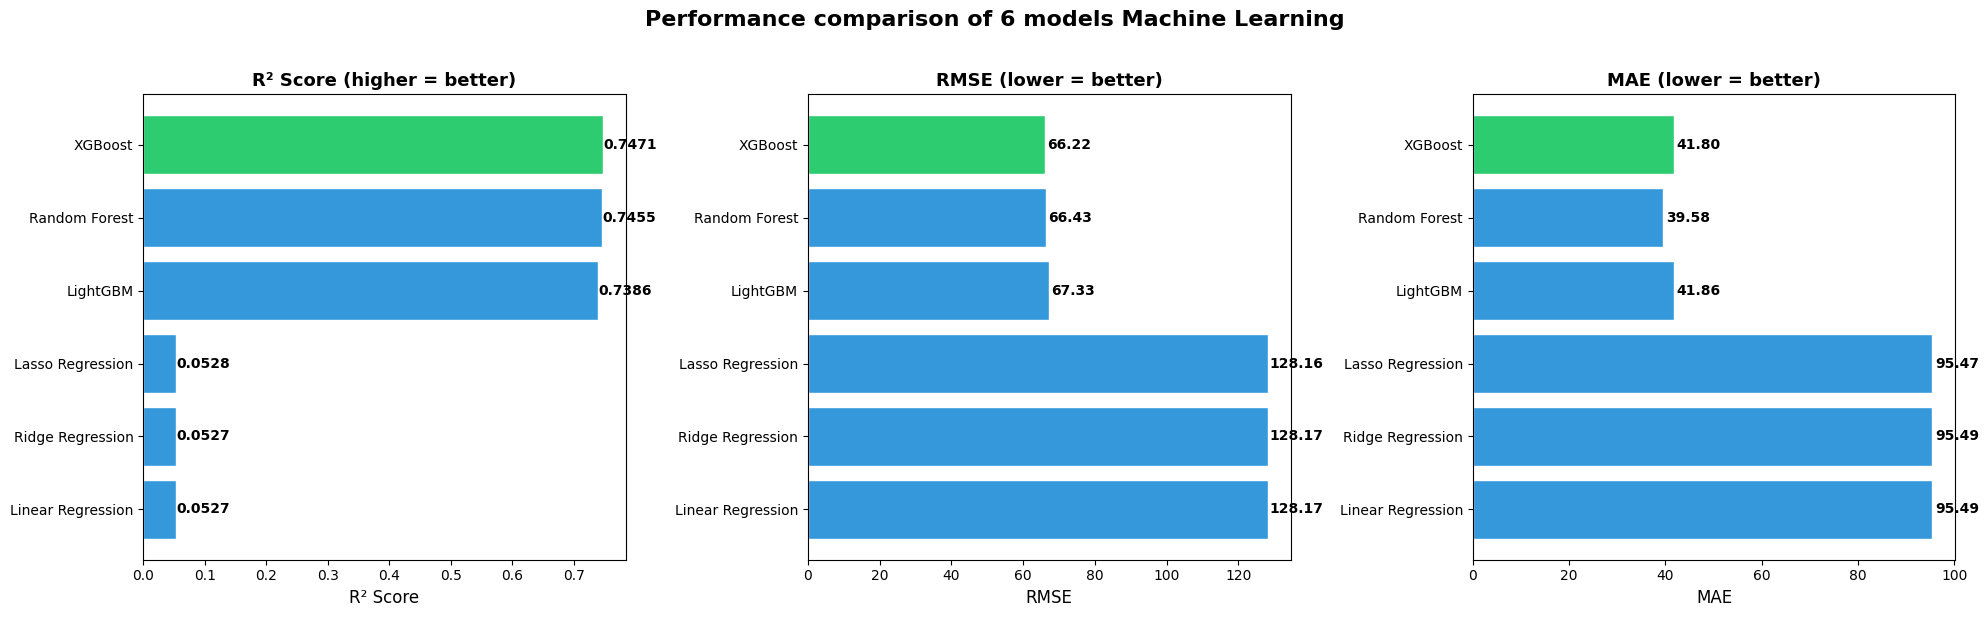

In [89]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Performance comparison of 6 models Machine Learning',
             fontsize=16, fontweight='bold', y=1.02)

models = results_df['Model'].tolist()
colors = ['#2ecc71' if m == best_model['Model'] else '#3498db' for m in models]

# --- Chart 1: R² Score ---
ax1 = axes[0]
bars1 = ax1.barh(models[::-1], results_df['R2_Score'].tolist()[::-1], color=colors[::-1], edgecolor='white')
ax1.set_xlabel('R² Score', fontsize=12)
ax1.set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars1, results_df['R2_Score'].tolist()[::-1]):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

# --- Chart 2: RMSE ---
ax2 = axes[1]
bars2 = ax2.barh(models[::-1], results_df['RMSE'].tolist()[::-1], color=colors[::-1], edgecolor='white')
ax2.set_xlabel('RMSE', fontsize=12)
ax2.set_title('RMSE (lower = better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars2, results_df['RMSE'].tolist()[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

# --- Chart 3: MAE ---
ax3 = axes[2]
bars3 = ax3.barh(models[::-1], results_df['MAE'].tolist()[::-1], color=colors[::-1], edgecolor='white')
ax3.set_xlabel('MAE', fontsize=12)
ax3.set_title('MAE (lower = better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars3, results_df['MAE'].tolist()[::-1]):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('charts_img/82_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3. BIỂU ĐỒ OVERFITTING CHECK (R² Train vs Test)

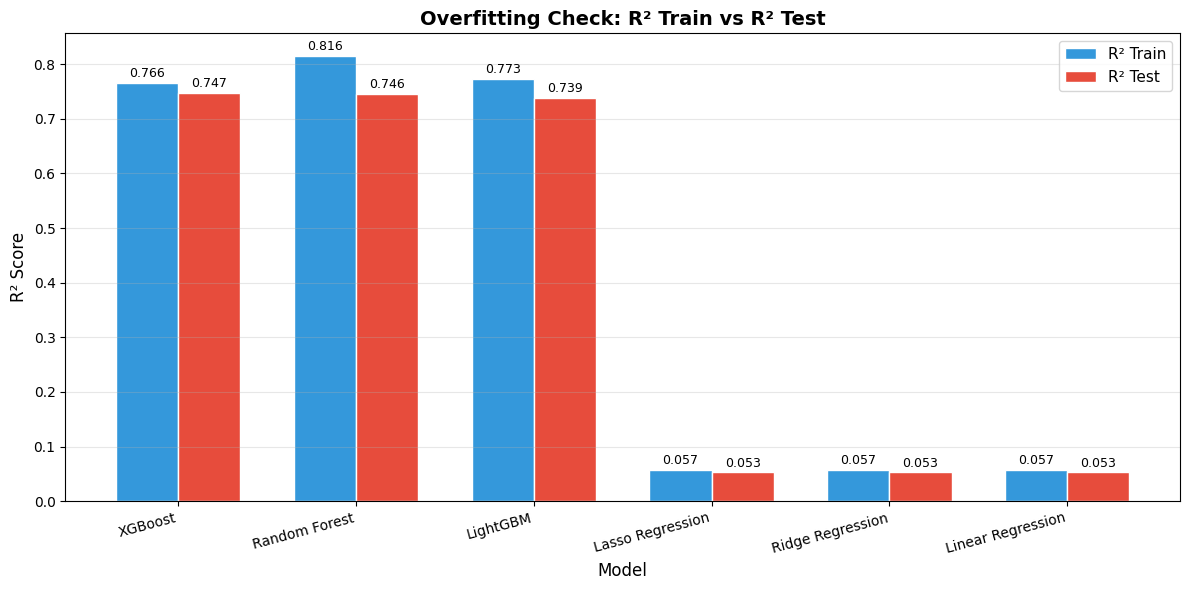

In [90]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models))
width = 0.35

r2_trains = results_df['R2_Train'].tolist()
r2_tests  = results_df['R2_Score'].tolist()

bars_train = ax.bar(x - width/2, r2_trains, width, label='R² Train', color='#3498db', edgecolor='white')
bars_test  = ax.bar(x + width/2, r2_tests,  width, label='R² Test',  color='#e74c3c', edgecolor='white')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('Overfitting Check: R² Train vs R² Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Thêm giá trị lên bars
for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('charts_img/83_overfitting_check.png', dpi=150, bbox_inches='tight')
plt.show()